# biPangolin paper figures

This notebook is a figure-generation workspace for the biPangolin manuscript:

1. **Correction optimisation** — empirical sweep + analytical estimate of the None-class correction factor `k`
2. **Example sequence and model runs** — load a worked example for the trace and tissue figures
3. **Effect of correction value on prediction traces** — the example sequence re-plotted at different `k` values, alongside Pangolin and SpliceAI
4. **Pangolin PSI / P(spliced) versus probe confidence** — does the probe fire where Pangolin says there's splicing?
5. **4-track-per-tissue matrix export** — optional NPY dump of the tissue-specific donor/acceptor predictions
6. **Held-out benchmark on chr1 + chr9** — large-scale PR-AUC comparison against SpliceAI and Pangolin alone
7. **Acceptor-vs-donor discrimination at true splice sites** — confusion matrix + signed-difference density showing near-perfect A/D classification given a true site
8. **Correlation analysis across models** — pairwise Spearman correlations between every probe / Pangolin / SpliceAI per-position score column

The notebook saves figures into `paper_figures/` as SVG and PNG.

## 0. Optional dependencies

Run this cell once if the current environment does not already contain the plotting / benchmarking dependencies.
SpliceAI pulls in TensorFlow, so it is intentionally optional.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

from bipangolin import BiPangolinRunner
from bipangolin.runner import score_sequence_or_long_sequence

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
})

FIG_DIR = Path("paper_figures")
FIG_DIR.mkdir(exist_ok=True)

ACC_COLOR = "#2f80ed"
DON_COLOR = "#eb5757"
NONE_COLOR = "#4f4f4f"
PANGOLIN_COLOR = "#27ae60"
PSI_COLOR = "#9b51e0"

def save_figure(fig, name):
    """Save a figure as SVG and PNG."""
    stem = FIG_DIR / name
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
    print(f"saved {stem.with_suffix('.svg')} and {stem.with_suffix('.png')}")

def tensor_to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

## 1. Correction optimisation summary

This first panel uses `optimal_correction.json` to show the empirical correction sweep and the analytical estimate. The more intuitive manuscript panel comes below, where the same example sequence is re-plotted after applying `k = 1, 10, 100, 1000` to the probe outputs.

In [2]:
def find_correction_json():
    candidates = [
        Path("src/bipangolin/data/probes/optimal_correction.json"),
        Path("bipangolin_probes/optimal_correction.json"),
    ]
    for path in candidates:
        if path.exists():
            return path

    try:
        from importlib.resources import files
        path = files("bipangolin") / "data" / "probes" / "optimal_correction.json"
        if path.is_file():
            return path
    except Exception:
        pass

    raise FileNotFoundError("Could not find optimal_correction.json")

correction_json = find_correction_json()
correction_json

PosixPath('src/bipangolin/data/probes/optimal_correction.json')

saved paper_figures/figure_correction_optimisation.svg and paper_figures/figure_correction_optimisation.png


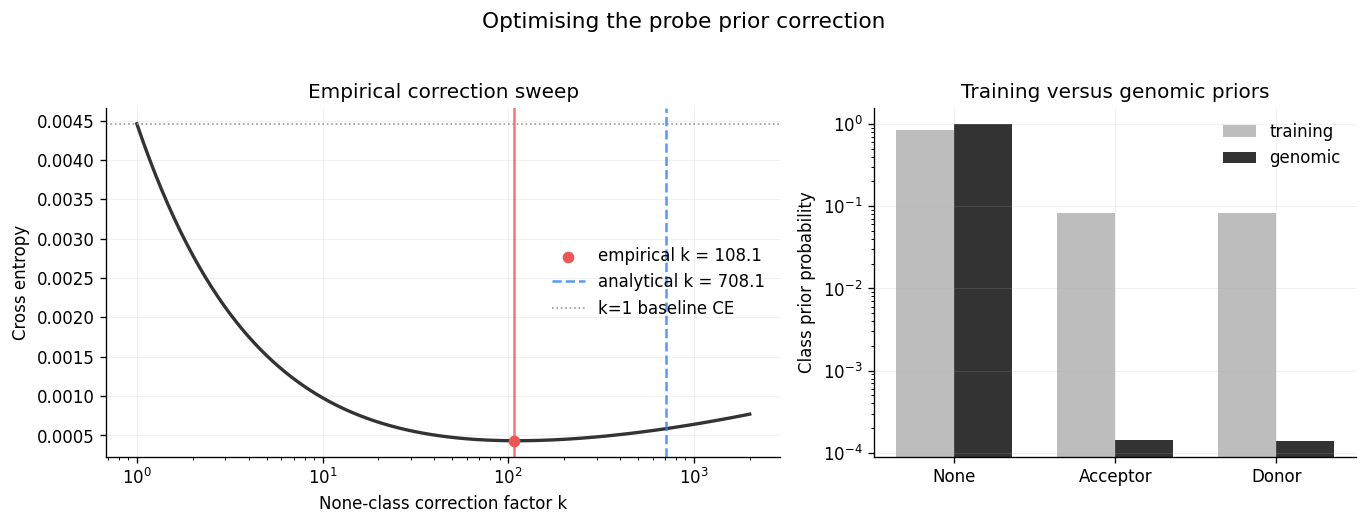

In [3]:
def plot_correction_optimisation(correction_path=correction_json):
    with open(correction_path) as f:
        correction = json.load(f)

    rows = correction["empirical_sweep"]["rows"]
    k = np.array([r["k"] for r in rows], dtype=float)
    ce = np.array([r["cross_entropy"] for r in rows], dtype=float)

    best_k = float(correction["empirical_sweep"]["best_k"])
    analytical_k = float(correction["analytical"]["analytical_k"])
    baseline_ce = float(correction["empirical_sweep"]["baseline_k1_cross_entropy"])

    real_dist = correction["analytical"]["real_distribution"]
    train_dist = correction["analytical"]["training_distribution"]
    classes = ["none", "acc", "don"]
    real = np.array([real_dist[f"p_{c}"] for c in classes])
    train = np.array([train_dist[f"p_{c}"] for c in classes])

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

    ax = axes[0]
    ax.plot(k, ce, color="#333333", lw=2)
    ax.scatter([best_k], [ce[np.argmin(np.abs(k - best_k))]], color=DON_COLOR, zorder=5, label=f"empirical k = {best_k:.1f}")
    ax.axvline(best_k, color=DON_COLOR, lw=1.5, alpha=0.8)
    ax.axvline(analytical_k, color=ACC_COLOR, lw=1.5, ls="--", alpha=0.8, label=f"analytical k = {analytical_k:.1f}")
    ax.axhline(baseline_ce, color="#999999", lw=1, ls=":", label="k=1 baseline CE")
    ax.set_xscale("log")
    ax.set_xlabel("None-class correction factor k")
    ax.set_ylabel("Cross entropy")
    ax.set_title("Empirical correction sweep")
    ax.legend(frameon=False)

    ax = axes[1]
    x = np.arange(len(classes))
    width = 0.36
    ax.bar(x - width/2, train, width, label="training", color="#bdbdbd")
    ax.bar(x + width/2, real, width, label="genomic", color="#333333")
    ax.set_yscale("log")
    ax.set_xticks(x, ["None", "Acceptor", "Donor"])
    ax.set_ylabel("Class prior probability")
    ax.set_title("Training versus genomic priors")
    ax.legend(frameon=False)

    fig.suptitle("Optimising the probe prior correction", y=1.03, fontsize=13)
    fig.tight_layout()
    return fig, correction

fig, correction = plot_correction_optimisation()
save_figure(fig, "figure_correction_optimisation")
plt.show()

## 2. Example sequence and model runs

This example sequence is used for the correction trace figure and the SpliceAI comparison. Replace `input_sequence` with a gene or region of interest for the final manuscript figure if needed.

In [4]:
# Load the example sequence from a FASTA file (single record). GAPDH here, but
# point INPUT_FASTA at any one-record FASTA to regenerate the trace figures.
INPUT_FASTA = Path("GAPDH.fasta")

def _read_single_fasta(path):
    header, seq = None, []
    for line in Path(path).read_text().splitlines():
        if line.startswith(">"):
            assert header is None, f"{path} has >1 record; expected a single sequence"
            header = line[1:].strip()
        elif line.strip():
            seq.append(line.strip())
    assert header is not None, f"no FASTA header found in {path}"
    return header, "".join(seq).upper()

input_header, input_sequence = _read_single_fasta(INPUT_FASTA)
print(f"{input_header}")
print(f"length: {len(input_sequence):,} nt")
len(input_sequence)

hg38_dna range=chr12:6534517-6538371 5'pad=0 3'pad=0 strand=+ repeatMasking=none
length: 3,855 nt


3855

In [5]:
import os
import subprocess
import sys
import tempfile
import textwrap

def get_spliceai_probs_subprocess(input_sequence, context=10000, python_exe=None):
    """Run SpliceAI in a fresh Python subprocess to avoid TF / torch crashes."""
    script = textwrap.dedent('''
        import sys, numpy as np
        seq = sys.argv[1]
        context = int(sys.argv[2])
        out_path = sys.argv[3]

        from pkg_resources import resource_filename
        from tensorflow.keras.models import load_model
        from spliceai.utils import one_hot_encode

        models = [load_model(resource_filename("spliceai", f"models/spliceai{i}.h5")) for i in range(1, 6)]
        x = one_hot_encode("N" * (context // 2) + seq + "N" * (context // 2))[None, :]
        y = np.mean([m.predict(x, verbose=0) for m in models], axis=0)
        np.savez(out_path, acceptor=y[0, :, 1], donor=y[0, :, 2])
    ''')

    with tempfile.NamedTemporaryFile("w", suffix=".py", delete=False) as f:
        f.write(script)
        script_path = f.name
    out_fd, out_path = tempfile.mkstemp(suffix=".npz")
    os.close(out_fd)
    try:
        subprocess.run(
            [python_exe or sys.executable, script_path, input_sequence, str(context), out_path],
            check=True,
        )
        data = np.load(out_path)
        acc = data["acceptor"]
        don = data["donor"]
        return acc, don, np.arange(len(acc))
    finally:
        for p in (script_path, out_path):
            if os.path.exists(p):
                os.unlink(p)

try:
    spliceai_acceptor, spliceai_donor, nt_pos = get_spliceai_probs_subprocess(input_sequence)
except Exception as e:
    spliceai_acceptor = spliceai_donor = nt_pos = None
    warnings.warn(f"SpliceAI could not be loaded/run: {e}")


/var/folders/kr/crxb3xqd4wv1ysx_0t4zgxv80000gn/T/tmpthmvzqu7.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 3. Figure: effect of correction value on prediction traces

This figure runs biPangolin once with `correction_k=1.0`, then applies different None-class correction values post hoc. Because the correction only rescales the three probe probabilities, this gives the same probe traces as rerunning the model with each `correction_k`, without wasting compute.

biPangolin: 12 model+probe pairs ready on mps
biPangolin: + 12 PSI-tuned models for PSI predictions (+ matching PSI-side probes attached)
saved paper_figures/figure_correction_value_traces.svg and paper_figures/figure_correction_value_traces.png


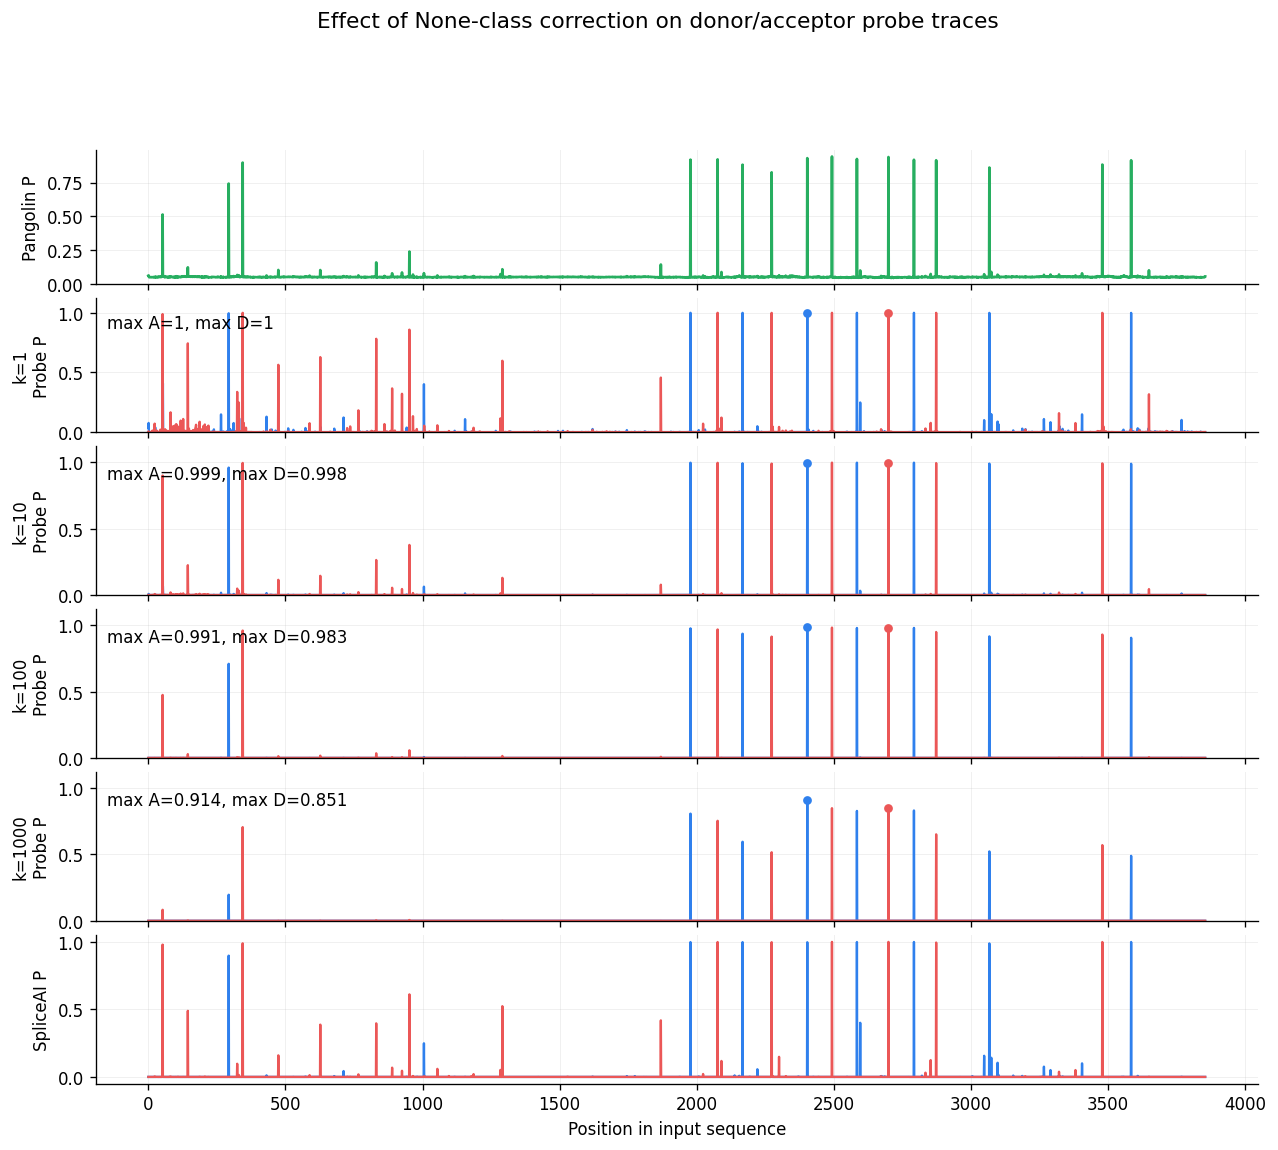

In [6]:
def apply_probe_correction(result, k):
    """Apply None-class correction k to an existing BiPangolinResult's probe tracks."""
    probs = np.stack([
        tensor_to_numpy(result.probe_none),
        tensor_to_numpy(result.probe_acceptor),
        tensor_to_numpy(result.probe_donor),
    ], axis=0).astype(float)
    probs[0] *= float(k)
    probs /= np.clip(probs.sum(axis=0, keepdims=True), 1e-12, None)
    return {
        "none": probs[0],
        "acceptor": probs[1],
        "donor": probs[2],
    }

def plot_correction_value_traces(
    raw_result,
    correction_values=(1, 10, 100, 1000),
    start=0,
    end=None,
    spliceai_acceptor=None,
    spliceai_donor=None,
    spliceai_x=None,
):
    if end is None:
        end = len(raw_result)
    x = np.arange(start, end)

    # Ensemble = mean across tissues (matches pangolin_p_ensemble used everywhere
    # else), rather than arbitrarily picking tissue 0. PSI is a different target
    # (usage, not presence) so it is intentionally omitted here.
    pangolin_p = tensor_to_numpy(raw_result.pangolin_prob).mean(axis=0)[start:end]

    corrected = {k: apply_probe_correction(raw_result, k) for k in correction_values}
    shared_ymax = max(
        max(corrected[k]["acceptor"][start:end].max(), corrected[k]["donor"][start:end].max())
        for k in correction_values
    )
    shared_ymax = max(0.01, shared_ymax * 1.12)

    has_spliceai = spliceai_acceptor is not None
    nrows = (1 if has_spliceai else 0) + 1 + len(correction_values)
    height_ratios = (
        ([0.9] if has_spliceai else [])
        + [0.9]
        + [1] * len(correction_values)
    )

    fig, axes = plt.subplots(
        nrows, 1,
        figsize=(12.5, 2.0 + 1.35 * nrows),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios, "hspace": 0.10},
    )
    axes = np.asarray(axes).ravel()

    row = 0

    ax = axes[row]
    ax.plot(x, pangolin_p, color=PANGOLIN_COLOR, lw=1.6, label="Pangolin P(spliced), ensemble")
    ax.set_ylabel("Pangolin P")
    row += 1

    for i, k in enumerate(correction_values):
        ax = axes[row]
        acc = corrected[k]["acceptor"][start:end]
        don = corrected[k]["donor"][start:end]
        ax.fill_between(x, acc, color=ACC_COLOR, alpha=0.18, lw=0)
        ax.plot(x, acc, color=ACC_COLOR, lw=1.4, label="acceptor")
        ax.fill_between(x, don, color=DON_COLOR, alpha=0.18, lw=0)
        ax.plot(x, don, color=DON_COLOR, lw=1.4, label="donor")
        ax.set_ylabel(f"k={k}\nProbe P")
        ax.set_ylim(0, shared_ymax)

        acc_peak = int(np.argmax(acc)) + start
        don_peak = int(np.argmax(don)) + start
        ax.scatter([acc_peak], [corrected[k]["acceptor"][acc_peak]], color=ACC_COLOR, s=18, zorder=4)
        ax.scatter([don_peak], [corrected[k]["donor"][don_peak]], color=DON_COLOR, s=18, zorder=4)
        ax.text(0.01, 0.78, f"max A={acc.max():.3g}, max D={don.max():.3g}", transform=ax.transAxes)
        row += 1

    if has_spliceai:
        sai_x = np.asarray(spliceai_x) if spliceai_x is not None else np.arange(len(spliceai_acceptor))
        mask = (sai_x >= start) & (sai_x < end)
        ax = axes[row]
        ax.plot(sai_x[mask], np.asarray(spliceai_acceptor)[mask], color=ACC_COLOR, lw=1.4, label="SpliceAI acceptor")
        ax.plot(sai_x[mask], np.asarray(spliceai_donor)[mask], color=DON_COLOR, lw=1.4, label="SpliceAI donor")
        ax.set_ylabel("SpliceAI P")
        row += 1

    axes[-1].set_xlabel("Position in input sequence")
    fig.suptitle("Effect of None-class correction on donor/acceptor probe traces", y=0.995, fontsize=13)
    return fig

# Raw / uncorrected probe probabilities. Pangolin P and PSI are unchanged by k.
raw_runner = BiPangolinRunner(tissue="all_tissues", correction_k=1.0, use_psi_models=True)
raw_result = raw_runner.score_sequence(input_sequence)

fig = plot_correction_value_traces(
    raw_result,
    correction_values=(1, 10, 100, 1000),
    spliceai_acceptor=globals().get("spliceai_acceptor"),
    spliceai_donor=globals().get("spliceai_donor"),
    spliceai_x=globals().get("nt_pos"),
)
save_figure(fig, "figure_correction_value_traces")
plt.show()

biPangolin: 12 model+probe pairs ready on mps
biPangolin: + 12 PSI-tuned models for PSI predictions (+ matching PSI-side probes attached)
biPangolin: correction k=108.1
saved paper_figures/figure_main_traces.svg and paper_figures/figure_main_traces.png


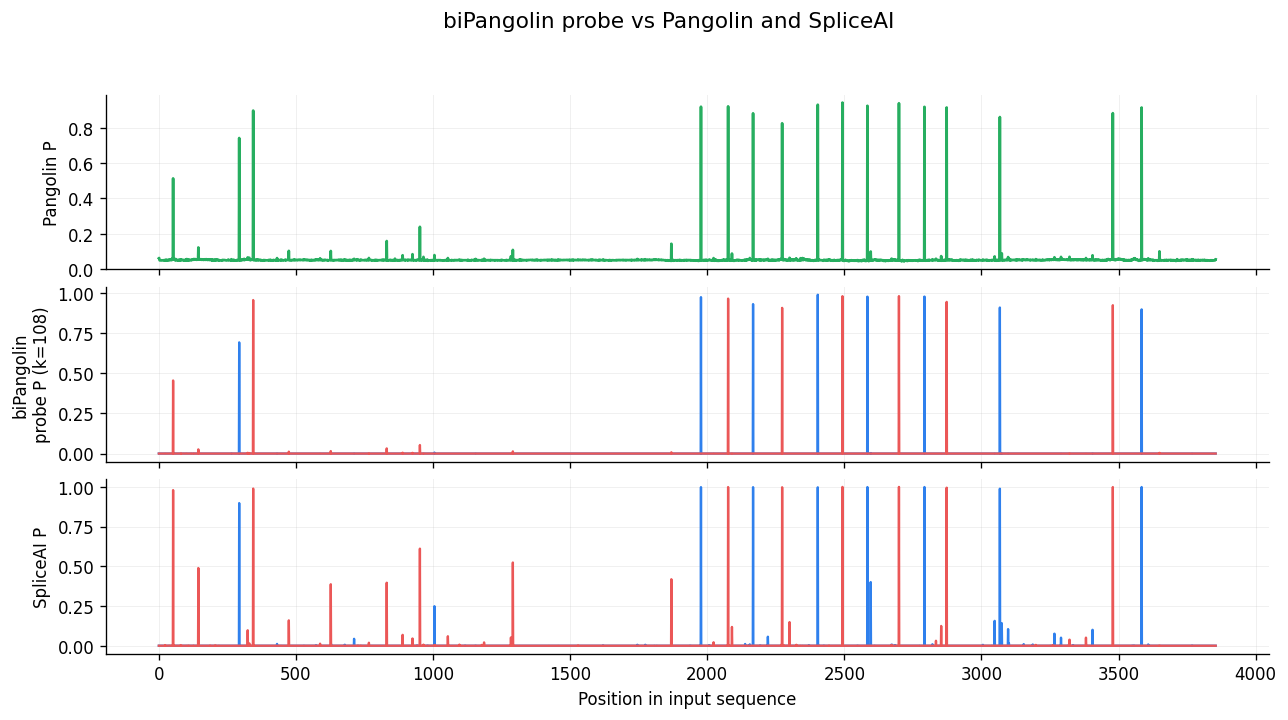

In [7]:
# Main-figure trace: Pangolin P, biPangolin probe (optimal k), SpliceAI — one
# acceptor/donor track each, no legends. The k-sweep version above is the supplement.
opt_runner = BiPangolinRunner(tissue="all_tissues", use_psi_models=True)  # default k = optimal
opt_result = opt_runner.score_sequence(input_sequence)


def plot_main_traces(result, k, start=0, end=None,
                     spliceai_acceptor=None, spliceai_donor=None, spliceai_x=None):
    if end is None:
        end = len(result)
    x = np.arange(start, end)
    pangolin_p = tensor_to_numpy(result.pangolin_prob).mean(axis=0)[start:end]
    acc = tensor_to_numpy(result.probe_acceptor)[start:end]
    don = tensor_to_numpy(result.probe_donor)[start:end]

    has_spliceai = spliceai_acceptor is not None
    nrows = 2 + (1 if has_spliceai else 0)
    fig, axes = plt.subplots(
        nrows, 1, figsize=(12.5, 2.0 + 1.35 * nrows),
        sharex=True, gridspec_kw={"hspace": 0.10},
    )
    axes = np.asarray(axes).ravel()

    axes[0].plot(x, pangolin_p, color=PANGOLIN_COLOR, lw=1.6)
    axes[0].set_ylabel("Pangolin P")

    axes[1].fill_between(x, acc, color=ACC_COLOR, alpha=0.18, lw=0)
    axes[1].plot(x, acc, color=ACC_COLOR, lw=1.4)
    axes[1].fill_between(x, don, color=DON_COLOR, alpha=0.18, lw=0)
    axes[1].plot(x, don, color=DON_COLOR, lw=1.4)
    axes[1].set_ylabel(f"biPangolin\nprobe P (k={k:.0f})")

    if has_spliceai:
        sai_x = np.asarray(spliceai_x) if spliceai_x is not None else np.arange(len(spliceai_acceptor))
        mask = (sai_x >= start) & (sai_x < end)
        axes[2].plot(sai_x[mask], np.asarray(spliceai_acceptor)[mask], color=ACC_COLOR, lw=1.4)
        axes[2].plot(sai_x[mask], np.asarray(spliceai_donor)[mask], color=DON_COLOR, lw=1.4)
        axes[2].set_ylabel("SpliceAI P")

    axes[-1].set_xlabel("Position in input sequence")
    fig.suptitle("biPangolin probe vs Pangolin and SpliceAI", y=0.995, fontsize=13)
    return fig


fig = plot_main_traces(
    opt_result, opt_runner.correction_k,
    spliceai_acceptor=globals().get("spliceai_acceptor"),
    spliceai_donor=globals().get("spliceai_donor"),
    spliceai_x=globals().get("nt_pos"),
)
save_figure(fig, "figure_main_traces")
plt.show()

In [8]:
# Use one tissue for simple example plots. Use tissue="all_tissues" for all tissue rows.
# use_psi_models=True loads the PSI-tuned Pangolin weight files in addition to
# the P-tuned ones, so result.pangolin_psi is populated. Doubles Pangolin
# inference compute, which is negligible at this scale.
runner = BiPangolinRunner(tissue="testis", use_psi_models=True)
bp_result = runner.score_sequence(input_sequence)
bp_result


biPangolin: 3 model+probe pairs ready on mps
biPangolin: + 3 PSI-tuned models for PSI predictions (+ matching PSI-side probes attached)
biPangolin: correction k=108.1


BiPangolinResult(pangolin_prob=tensor([[0.0624, 0.0722, 0.0522,  ..., 0.0518, 0.0530, 0.0541]]), probe_none=tensor([0.9996, 0.9982, 1.0000,  ..., 1.0000, 1.0000, 1.0000]), probe_acceptor=tensor([3.9886e-04, 1.8006e-03, 3.0774e-06,  ..., 7.0467e-06, 1.4753e-06,
        9.8244e-07]), probe_donor=tensor([9.2545e-06, 7.6982e-06, 1.6415e-06,  ..., 1.2257e-06, 3.0409e-06,
        1.0029e-06]), tissues=('testis',), pangolin_psi=tensor([[8.8290e-04, 1.6717e-03, 1.4956e-05,  ..., 7.7079e-06, 4.8774e-05,
         4.0171e-05]]), metadata={'length': 3855, 'tiled': False, 'psi_only': False, 'output_unscaled_values': False}, probe_per_tissue=None, probe_per_tissue_psi=None)

## 5. Optional: export the 4-track-per-tissue matrix

Channel order:

0. donor PSI
1. donor P(spliced)
2. acceptor PSI
3. acceptor P(spliced)

In [9]:
# Rebuild the 4-track (acceptor/donor x PSI/P) tissue matrix from routed_tracks().
# four_track_per_tissue() was removed; routed_tracks() returns (prob_routed,
# psi_routed), each (2, n_tissues, L) with channel 0=acceptor, 1=donor.
# Channel order here follows biPangolin's universal convention: acceptor first,
# then donor (same as routed_tracks, the CLI bedGraphs, and the VCF deltas):
#   0: acceptor PSI   1: acceptor P   2: donor PSI   3: donor P
# Needs use_psi_models=True (set on the runner above) so pangolin_psi exists.
prob_routed, psi_routed = bp_result.routed_tracks()
prob_routed = prob_routed.detach().cpu().numpy()
psi_routed = psi_routed.detach().cpu().numpy()
four_track = np.stack([
    psi_routed[0],   # acceptor PSI
    prob_routed[0],  # acceptor P
    psi_routed[1],   # donor PSI
    prob_routed[1],  # donor P
])
np.save(FIG_DIR / "example_four_track_per_tissue.npy", four_track)
four_track.shape

(4, 1, 3855)

## 6. Held-out benchmark: chr1 + chr9

Large-scale comparison on the held-out test chromosomes (chr1, chr9 — forward strand only, same TSS/TTS-aware labelling as training).

The actual model inference is done outside the notebook by `benchmark/bench_score.py` (writes `bench_scores/{chrom}.parquet`). Metrics are computed by `benchmark/bench_metrics.py` (writes `bench_metrics/summary.csv`).

This section loads those artifacts and produces:

1. PR-AUC bar chart by method × task (the headline figure)
2. Score distributions at true acceptor / donor sites
3. Overlaid PR curves
4. Top-N recall

Run the benchmark scripts first if `bench_metrics/summary.csv` doesn't exist.

In [10]:
# Load the benchmark summary CSV produced by `benchmark/bench_metrics.py`.

import pandas as pd

BENCH_SCORES_DIR = Path("bench_scores")
BENCH_METRICS_CSV = Path("bench_metrics/summary.csv")

if not BENCH_METRICS_CSV.exists():
    raise FileNotFoundError(
        f"{BENCH_METRICS_CSV} not found. Run:\n"
        "  python benchmark/bench_metrics.py --scores bench_scores/ --out bench_metrics/summary.csv"
    )

bench_summary = pd.read_csv(BENCH_METRICS_CSV)
print(f"loaded {len(bench_summary):,} rows from {BENCH_METRICS_CSV}")
print("chroms:   ", sorted(bench_summary['chrom'].unique()))
print("methods:  ", sorted(bench_summary['method'].unique()))
print("tasks:    ", sorted(bench_summary['task'].unique()))
print("metrics:  ", sorted(bench_summary['metric'].unique()))
bench_summary.head()

loaded 636 rows from bench_metrics/summary.csv
chroms:    ['ALL', 'chr1', 'chr9']
methods:   ['biPangolin_k0', 'biPangolin_k1', 'biPangolin_k10', 'biPangolin_k100', 'biPangolin_k1000', 'biPangolin_k502', 'biPangolin_psi_k0', 'biPangolin_psi_k1', 'biPangolin_psi_k10', 'biPangolin_psi_k100', 'biPangolin_psi_k1000', 'biPangolin_psi_k502', 'pangolin_p_brain', 'pangolin_p_heart', 'pangolin_p_liver', 'pangolin_p_testis', 'pangolin_psi_brain', 'pangolin_psi_heart', 'pangolin_psi_liver', 'pangolin_psi_testis', 'spliceai']
tasks:     ['3class_argmax', 'acceptor', 'any_site', 'donor']
metrics:   ['accuracy_all', 'accuracy_at_truesites', 'pr_auc', 'roc_auc', 'top_n_precision', 'top_n_recall']


,chrom,method,task,metric,value,n_pos,n_total
0,chr1,biPangolin_k0,acceptor,pr_auc,0.607221,16041,134872235
1,chr1,biPangolin_k0,acceptor,roc_auc,0.997372,16041,134872235
2,chr1,biPangolin_k0,acceptor,top_n_recall,0.611122,16041,134872235
3,chr1,biPangolin_k0,acceptor,top_n_precision,0.611122,16041,134872235
4,chr1,biPangolin_k0,donor,pr_auc,0.623070,15943,134872235


In [11]:
# Load the raw parquet (memory-efficient column-selective read).
# We need: label + the score columns we plot. We DON'T need chrom/gene_id/pos for these analyses.
#
# Probe outputs are stored in the parquet at correction_k=1.0 (raw softmax). We
# apply the Bayesian none-class correction at load time, defaulting to the
# production k from optimal_correction.json (~502). Pass correction_k=1.0 if
# you specifically want to look at raw outputs.

import pyarrow.parquet as pq

# Set to ["chr1", "chr9"] for final paper figures; chr9-only for quick local runs.
BENCH_CHROMS = ["chr1", "chr9"]


def _resolve_default_correction_k():
    """Read best_k from src/bipangolin/data/probes/optimal_correction.json."""
    for p in (Path("src/bipangolin/data/probes/optimal_correction.json"),
              Path("bipangolin_probes/optimal_correction.json")):
        if p.exists():
            with open(p) as f:
                return float(json.load(f)["empirical_sweep"]["best_k"])
    return 0.0  # fallback if the file can't be found


def load_bench_arrays(chroms=BENCH_CHROMS, scores_dir=BENCH_SCORES_DIR,
                     correction_k=None):
    if correction_k is None:
        correction_k = _resolve_default_correction_k()

    cols = [
        "chrom", "pos",
        "label",
        "probe_none", "probe_acc", "probe_don",
        "pangolin_p_heart", "pangolin_p_liver", "pangolin_p_brain", "pangolin_p_testis",
        "pangolin_psi_heart", "pangolin_psi_liver", "pangolin_psi_brain", "pangolin_psi_testis",
        "spliceai_acc", "spliceai_don",
    ]
    tables = []
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        print(f"  reading {path} ...")
        tables.append(pq.read_table(str(path), columns=cols))
    table = pa.concat_tables(tables)
    print(f"  total rows: {table.num_rows:,}   applying correction_k = {correction_k}")
    arrays = {}
    for c in cols:
        a = table[c].to_numpy()
        if c == "label":
            arrays[c] = a.astype(np.int8)
        elif c == "pos":
            arrays[c] = a.astype(np.int64)
        elif c == "chrom":
            arrays[c] = a  # keep as str/object for the relabel key
        else:
            arrays[c] = a.astype(np.float32)

    # --- Fix the per-gene labelling bug (bench_score.py:344-348) cheaply, in
    # place, without re-scoring. A genomic position that is a real splice site
    # in ANY overlapping gene was emitted as 'none' by the other gene's rows
    # (identical sequence, identical score). The correct label for a
    # (chrom, pos) is the max label across its duplicate rows: none(0) < acc(1)
    # < don(2), and acc/don conflicts were already dropped upstream.
    import pandas as pd
    chrom_codes = pd.factorize(arrays["chrom"])[0].astype(np.int64)
    key = chrom_codes * (int(arrays["pos"].max()) + 1) + arrays["pos"]
    lab = arrays["label"]
    fixed = pd.Series(lab).groupby(key).transform("max").to_numpy().astype(np.int8)
    n_changed = int((fixed != lab).sum())
    print(f"  relabelled {n_changed:,} none->site rows (overlapping-gene fix)")
    arrays["label"] = fixed

    # Apply Bayesian correction to probe triple (ensemble).
    if correction_k != 1.0:
        k = np.float32(correction_k)
        pn, pa_, pd_ = arrays["probe_none"], arrays["probe_acc"], arrays["probe_don"]
        s = pn * k + pa_ + pd_
        s = np.maximum(s, np.float32(1e-12))
        arrays["probe_none"] = (pn * k) / s
        arrays["probe_acc"]  = pa_ / s
        arrays["probe_don"]  = pd_ / s
    arrays["_correction_k"] = correction_k
    return arrays


import pyarrow as pa
bench_arrays = load_bench_arrays()

label = bench_arrays["label"]
print(f"  acceptors: {int((label==1).sum()):,}   donors: {int((label==2).sum()):,}   "
      f"none: {int((label==0).sum()):,}")


  reading bench_scores/chr1.parquet ...
  reading bench_scores/chr9.parquet ...
  total rows: 198,772,594   applying correction_k = 108.13542142817668
  relabelled 8,796 none->site rows (overlapping-gene fix)
  acceptors: 27,603   donors: 27,481   none: 198,717,510


In [ ]:
# PR curves overlaid: biPangolin probe vs SpliceAI vs Pangolin per tissue.
# Assumes bench_arrays was already loaded with the production k correction
# applied (load_bench_arrays default). Heavy lifting (sort + cumsum) cached to
# bench_metrics/pr_curves_cache.npz so re-running is instant.
# Delete the cache to recompute.

import time

_TRAPZ = getattr(np, "trapezoid", None) or np.trapz
_PR_CACHE = Path("bench_metrics/pr_curves_cache.npz")
_PR_CURVE_POINTS = 5000


def _pr_curve(score, y):
    mask = np.isfinite(score)
    if not mask.all():
        score = score[mask]; y = y[mask]
    order = np.argsort(-score, kind="quicksort")
    y_sorted = y[order].astype(np.int32, copy=False)
    tp = np.cumsum(y_sorted, dtype=np.int64)
    fp = np.cumsum(1 - y_sorted, dtype=np.int64)
    n_pos = max(int(y_sorted.sum()), 1)
    recall = tp / n_pos
    precision = tp / np.maximum(tp + fp, 1)
    return recall, precision


def _pr_auc_from_curve(recall, precision):
    return float(_TRAPZ(
        np.concatenate([[1.0], precision]),
        np.concatenate([[0.0], recall]),
    ))


def _downsample_curve(recall, precision, n_points=_PR_CURVE_POINTS):
    # Log-spaced indices so the elbow at low recall (top of the sorted array,
    # where the curve actually has structure) is captured densely. Linear
    # spacing across 10s of millions of ranks collapses the elbow into 1-2
    # points and produces triangular curves.
    n = len(recall)
    if n <= n_points:
        return recall, precision
    raw = np.geomspace(1, n, n_points).astype(np.int64) - 1
    idx = np.unique(np.clip(raw, 0, n - 1))
    return recall[idx], precision[idx]


def _series_key(name):
    return name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")


def build_pr_curves(arrays, force_recompute=False):
    if _PR_CACHE.exists() and not force_recompute:
        z = np.load(_PR_CACHE, allow_pickle=False)
        curves = {}
        for k in z.files:
            if not k.endswith("__recall"):
                continue
            base = k[:-len("__recall")]
            task, _, raw_name = base.partition("::")
            curves[base] = {
                "recall": z[base + "__recall"],
                "precision": z[base + "__precision"],
                "auc": float(z[base + "__auc"][0]),
                "task": task,
                "display_name": raw_name.replace("_", " "),
            }
        print(f"  loaded cached PR curves from {_PR_CACHE}")
        return curves

    label = arrays["label"]
    is_acc = (label == 1).astype(np.int8)
    is_don = (label == 2).astype(np.int8)
    is_any = (label != 0).astype(np.int8)

    # arrays is assumed pre-corrected by load_bench_arrays.
    bp_acc  = arrays["probe_acc"]
    bp_don  = arrays["probe_don"]
    bp_none = arrays["probe_none"]
    k = arrays.get("_correction_k", "?")
    k_lbl = f"{k:.0f}" if isinstance(k, (int, float)) else k

    pangolin_p_ensemble = np.mean(
        np.stack([arrays[f"pangolin_p_{t}"] for t in ("heart", "liver", "brain", "testis")], axis=0),
        axis=0,
    )

    spec = [
        ("acceptor",        is_acc, f"biPangolin probe_acc k={k_lbl}",        bp_acc),
        ("acceptor",        is_acc, "SpliceAI acceptor",                       arrays["spliceai_acc"]),
        ("donor",           is_don, f"biPangolin probe_don k={k_lbl}",        bp_don),
        ("donor",           is_don, "SpliceAI donor",                          arrays["spliceai_don"]),
        ("any splice site", is_any, f"biPangolin 1-p_none k={k_lbl}",         1.0 - bp_none),
        ("any splice site", is_any, "SpliceAI max(A,D)",                       np.maximum(arrays["spliceai_acc"], arrays["spliceai_don"])),
        ("any splice site", is_any, "Pangolin P(spliced) ensemble",           pangolin_p_ensemble),
    ]

    curves = {}
    save_dict = {}
    for task, y, name, score in spec:
        t0 = time.time()
        r, p = _pr_curve(score, y)
        auc = _pr_auc_from_curve(r, p)
        r_ds, p_ds = _downsample_curve(r, p)
        key = f"{task}::{_series_key(name)}"
        curves[key] = {"recall": r_ds.astype(np.float32),
                       "precision": p_ds.astype(np.float32),
                       "auc": auc,
                       "task": task,
                       "display_name": name}
        save_dict[key + "__recall"]    = curves[key]["recall"]
        save_dict[key + "__precision"] = curves[key]["precision"]
        save_dict[key + "__auc"]       = np.array([auc], dtype=np.float64)
        print(f"  {task:18s} {name:40s}  AUC={auc:.4f}  ({time.time()-t0:.1f}s)")

    _PR_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(_PR_CACHE, **save_dict)
    print(f"  wrote {_PR_CACHE}")
    return curves


def plot_benchmark_pr_curves(arrays, force_recompute=False):
    curves = build_pr_curves(arrays, force_recompute=force_recompute)

    colour_map = {
        "biPangolin": "#2f80ed",
        "SpliceAI":   "#eb5757",
        "Pangolin P": "#27ae60",
        "Pangolin PSI": "#9b51e0",
    }
    def _colour(name):
        for prefix, c in colour_map.items():
            if name.startswith(prefix):
                return c
        return "#888888"

    task_order = ["acceptor", "donor", "any splice site"]
    series_per_task = {t: [] for t in task_order}
    for d in curves.values():
        series_per_task.setdefault(d["task"], []).append(d)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
    for ax, task in zip(axes, task_order):
        for d in series_per_task[task]:
            name = d["display_name"]
            ax.plot(d["recall"], d["precision"], color=_colour(name), lw=1.4,
                    label=f"{name}  (AUC={d['auc']:.2f})")
        ax.set_title(task, fontsize=12)
        ax.set_xlabel("recall", fontsize=11)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        ax.tick_params(labelsize=10)
        ax.legend(frameon=False, fontsize=10, loc="lower left")
    axes[0].set_ylabel("precision", fontsize=11)
    fig.suptitle("Precision–recall curves on held-out chr1 + chr9", y=1.02, fontsize=13)
    fig.tight_layout()
    return fig


fig = plot_benchmark_pr_curves(bench_arrays)
save_figure(fig, "figure_benchmark_pr_curves")
plt.show()

SyntaxError: invalid syntax (310111277.py, line 1)

### Robustness of the benchmark to the correction factor k

The none-class correction `k` rescales the probe posterior. Because it renormalises a 3-class softmax (folding `p_none` into every score), it is **not** a monotonic transform of `p_acc`/`p_don`, so in principle it could reorder positions and shift AUPRC. In practice the probe outputs are sharply bimodal (a position is confidently a site or confidently not), so the ranking — and therefore AUPRC — is **invariant across every sensible k**. Only the degenerate `k=0` (which discards the none class entirely) breaks it. This shows the headline benchmark is not an artifact of the chosen k (nor of the 10:1 training class balance, whose first-order effect is exactly a single value of k).

biPangolin probe AUPRC vs k (n_pos-weighted):
        acceptor   donor  any_site
k=0       0.6048  0.6182    0.0002
k=1       0.7343  0.7205    0.7273
k=10      0.7343  0.7205    0.7273
k=100     0.7343  0.7205    0.7273
k=502     0.7343  0.7205    0.7273
k=1000    0.7343  0.7205    0.7273

SpliceAI (k-independent): {'acceptor': 0.6953, 'donor': 0.6878, 'any_site': 0.6914}

range over k>=1: {'acceptor': np.float64(0.0), 'donor': np.float64(0.0), 'any_site': np.float64(0.0)}
saved paper_figures/figure_k_sensitivity.svg and paper_figures/figure_k_sensitivity.png


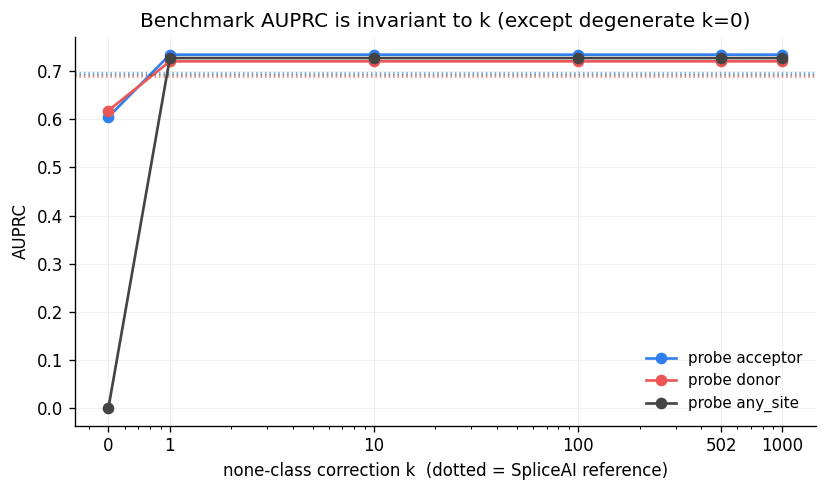

In [13]:
# AUPRC vs k, read straight from bench_metrics/summary.csv (the metrics sbatch
# swept k in {0,1,10,100,502,1000}). n_pos-weighted across whatever chroms are
# present. SpliceAI is k-independent and drawn as a reference line.
import pandas as pd

_sens = pd.read_csv(Path('bench_metrics/summary.csv'))
_pr = _sens[_sens.metric == 'pr_auc']

def _pooled(method, task):
    s = _pr[(_pr.method == method) & (_pr.task == task)]
    return float(np.average(s.value, weights=s.n_pos)) if len(s) else np.nan

_ks = [0, 1, 10, 100, 502, 1000]
_tasks = ['acceptor', 'donor', 'any_site']
_tab = pd.DataFrame(
    {t: [_pooled(f'biPangolin_k{k}', t) for k in _ks] for t in _tasks},
    index=[f'k={k}' for k in _ks])
print('biPangolin probe AUPRC vs k (n_pos-weighted):')
print(_tab.round(4).to_string())
_spl = {t: _pooled('spliceai', t) for t in _tasks}
print('\nSpliceAI (k-independent):', {t: round(v, 4) for t, v in _spl.items()})
print('\nrange over k>=1:',
      {t: round(_tab[t].iloc[1:].max() - _tab[t].iloc[1:].min(), 4) for t in _tasks})

fig, ax = plt.subplots(figsize=(7, 4.2))
_task_colour = {'acceptor': ACC_COLOR, 'donor': DON_COLOR, 'any_site': '#444444'}
_kpos = [max(k, 0.5) for k in _ks]  # 0 -> 0.5 so it sits on the log axis
for t in _tasks:
    ax.plot(_kpos, _tab[t].values, 'o-', color=_task_colour[t], lw=1.6, label=f'probe {t}')
    ax.axhline(_spl[t], color=_task_colour[t], lw=1.0, ls=':', alpha=0.7)
ax.set_xscale('log')
ax.set_xticks(_kpos); ax.set_xticklabels([str(k) for k in _ks])
ax.set_xlabel('none-class correction k  (dotted = SpliceAI reference)')
ax.set_ylabel('AUPRC')
ax.set_title('Benchmark AUPRC is invariant to k (except degenerate k=0)')
ax.legend(frameon=False, fontsize=9, loc='lower right')
fig.tight_layout()
save_figure(fig, 'figure_k_sensitivity')
plt.show()

### Which k best matches the probe's value distribution to Pangolin / SpliceAI?

k doesn't move ranking metrics (above), but it *does* reshape the probe's value distribution. Here we ask which k makes the **marginal distribution** of the corrected probe score look most like Pangolin's `P(spliced)` or SpliceAI's `max(acc,don)`, over a uniform genome-wide sample (≈99.97% non-sites, i.e. the real distribution, dominated by background). Distance = 1-Wasserstein (earth-mover) between the value sets; we also report KS.

**Caveat baked into the QQ plots:** Pangolin saturates roughly in [0.05, 0.95] while the probe spans 0→1. QQ/Wasserstein compare *values* (not ranks), so this support mismatch is irreducible — no k flattens the probe onto Pangolin's range at the extremes. The optimal k is partly chasing Pangolin's saturation, so this is a descriptive scale-matching analysis, **not** a replacement for the principled (genomic-prior) calibration k.

sampled 5,000,000 of 63,900,359 positions on chr9
pangolin_p range [0.000, 0.998]   spliceai range [0.000, 1.000]

W1-optimal k: {'Pangolin P': 56.2, 'SpliceAI max': 75.0}
min W1      : {'Pangolin P': 0.0004, 'SpliceAI max': 0.0}
W1 spread over k (flat => no real optimum): {'Pangolin P': 0.0023, 'SpliceAI max': 0.0031}
  KS(Pangolin P) at k=56 = 0.4670
  KS(SpliceAI max) at k=75 = 0.7912
saved paper_figures/figure_k_distribution_match.svg and paper_figures/figure_k_distribution_match.png


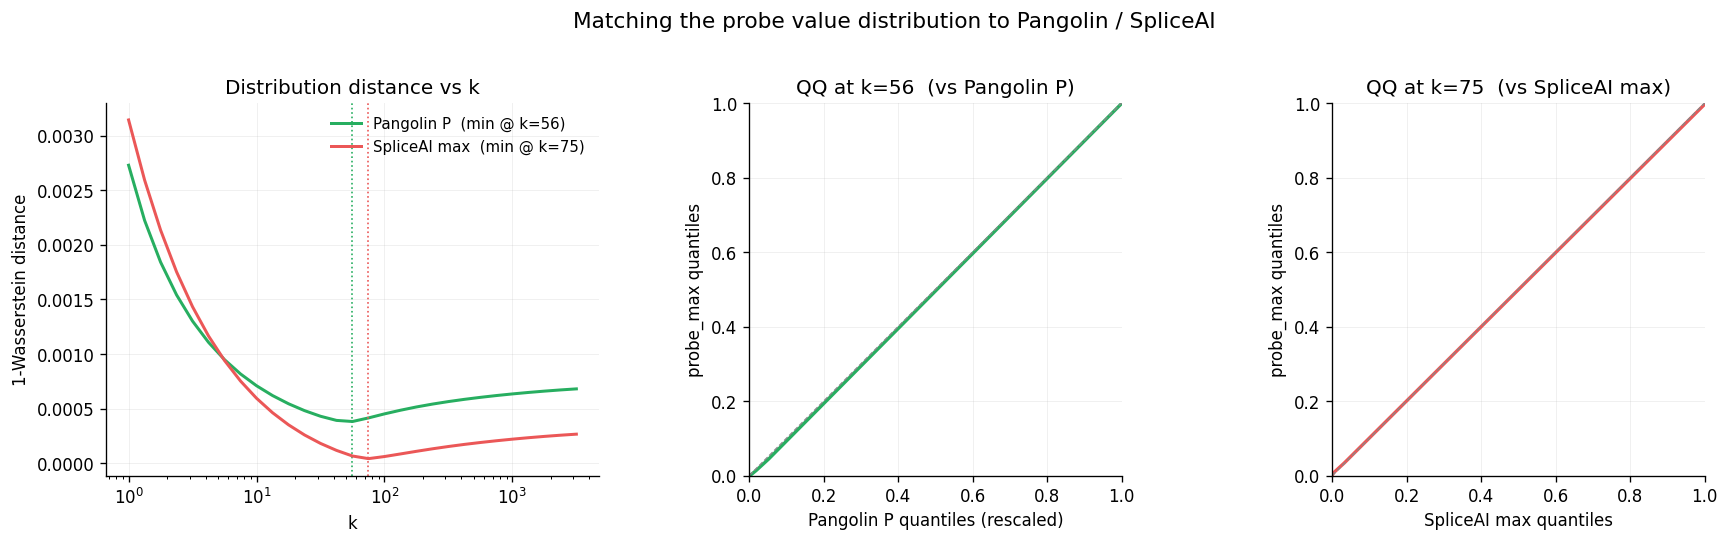

In [14]:
from scipy.stats import ks_2samp

_DIST_CHROM = 'chr9'           # one chrom is plenty for a marginal-distribution fit
_N_SAMPLE   = 5_000_000        # uniform genome-wide subsample (=~whole-lot distribution)
_RNG        = np.random.default_rng(0)

_cols = ['probe_none','probe_acc','probe_don',
         'pangolin_p_heart','pangolin_p_liver','pangolin_p_brain','pangolin_p_testis',
         'spliceai_acc','spliceai_don']
_t = pq.read_table(str(BENCH_SCORES_DIR / f'{_DIST_CHROM}.parquet'), columns=_cols)
_n = _t.num_rows
_idx = np.sort(_RNG.choice(_n, size=min(_N_SAMPLE, _n), replace=False))
_g = {c: _t[c].to_numpy()[_idx].astype(np.float64) for c in _cols}
del _t
print(f'sampled {len(_idx):,} of {_n:,} positions on {_DIST_CHROM}')

_pn, _pa, _pdn = _g['probe_none'], _g['probe_acc'], _g['probe_don']
_pang = np.mean([_g[f'pangolin_p_{t}'] for t in ('heart','liver','brain','testis')], axis=0)
_spl  = np.maximum(_g['spliceai_acc'], _g['spliceai_don'])
# Undo Pangolin's saturation (~[0.05,0.95]) so the match reflects distribution
# SHAPE rather than its compressed range; SpliceAI already spans [0,1].
_PANG_LO, _PANG_HI = 0.05, 0.95
_pang = np.clip((_pang - _PANG_LO) / (_PANG_HI - _PANG_LO), 0.0, 1.0)
print(f'pangolin_p range [{_pang.min():.3f}, {_pang.max():.3f}]   '
      f'spliceai range [{_spl.min():.3f}, {_spl.max():.3f}]')

def _probe_max(k):
    s = np.maximum(k*_pn + _pa + _pdn, 1e-12)
    return np.maximum(_pa/s, _pdn/s)

# Equal-size samples -> 1-Wasserstein = mean|sort(a)-sort(b)| (the L1 QQ distance).
# Sort each reference once; one sort per k. Much faster than scipy re-sorting.
_ks = np.unique(np.r_[1.0, np.logspace(0, 3.5, 29)])   # 1 .. ~3162
_refs = {'Pangolin P': np.sort(_pang), 'SpliceAI max': np.sort(_spl)}
_w = {r: [] for r in _refs}
for k in _ks:
    pms = np.sort(_probe_max(k))
    for r, ref_sorted in _refs.items():
        _w[r].append(float(np.mean(np.abs(pms - ref_sorted))))
_w = {r: np.array(v) for r, v in _w.items()}
_kbest = {r: float(_ks[int(np.argmin(_w[r]))]) for r in _refs}
_wmin  = {r: float(_w[r].min()) for r in _refs}
_wspread = {r: float(_w[r].max() - _w[r].min()) for r in _refs}
print('\nW1-optimal k:', {r: round(v,1) for r,v in _kbest.items()})
print('min W1      :', {r: round(v,4) for r,v in _wmin.items()})
print('W1 spread over k (flat => no real optimum):', {r: round(v,4) for r,v in _wspread.items()})
_refs_raw = {'Pangolin P': _pang, 'SpliceAI max': _spl}
for r in _refs:
    ks_at = ks_2samp(_probe_max(_kbest[r]), _refs_raw[r]).statistic
    print(f'  KS({r}) at k={_kbest[r]:.0f} = {ks_at:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
for r, col in (('Pangolin P', PANGOLIN_COLOR), ('SpliceAI max', '#eb5757')):
    ax.plot(_ks, _w[r], '-', color=col, lw=1.8, label=f'{r}  (min @ k={_kbest[r]:.0f})')
    ax.axvline(_kbest[r], color=col, ls=':', lw=1)
ax.set_xscale('log'); ax.set_xlabel('k'); ax.set_ylabel('1-Wasserstein distance')
ax.set_title('Distribution distance vs k'); ax.legend(frameon=False, fontsize=9)

_qs = np.linspace(0, 1, 1000)
for ax, (r, ref_raw), col in zip(axes[1:], _refs_raw.items(), (PANGOLIN_COLOR, '#eb5757')):
    pm = _probe_max(_kbest[r])
    ax.plot(np.quantile(ref_raw, _qs), np.quantile(pm, _qs), color=col, lw=2)
    ax.plot([0,1],[0,1], color='#888', ls='--', lw=0.8)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(f'{r} quantiles' + (' (rescaled)' if r=='Pangolin P' else '')); ax.set_ylabel('probe_max quantiles')
    ax.set_title(f'QQ at k={_kbest[r]:.0f}  (vs {r})')
fig.suptitle('Matching the probe value distribution to Pangolin / SpliceAI', y=1.02, fontsize=13)
fig.tight_layout()
save_figure(fig, 'figure_k_distribution_match')


### Probe-vs-reference scatters across k (standalone — pick your favourites)

Each scatter is saved as its own figure so you can choose. We show the corrected probe `max(acc,don)` against three references — Pangolin (raw), Pangolin rescaled to [0,1] via `(p-0.05)/0.9`, and SpliceAI `max` — at **k=1**, the **default** (from `optimal_correction.json`), and each model's **distribution-matched k** (Pangolin-rescaled ≈56, SpliceAI ≈75). True acceptor/donor sites are coloured; a background sample (grey) is included so the effect of k — which mostly squashes weak/background positions — is visible (it barely moves confident true sites, where `p_none≈0`). Spearman ρ is shown on the true-site subset (and is ~k-invariant).

In [15]:
# Load true sites + a background sample from the RAW (k=1) parquet so any k can be
# re-applied on the fly. Loads once into module-level _sc_* arrays.
import scipy.stats as _sps
import json as _json

_SCAT_BG = 30_000
_RNG_SC  = np.random.default_rng(1)
_TISS    = ('heart', 'liver', 'brain', 'testis')
_need = (['label', 'probe_none', 'probe_acc', 'probe_don', 'spliceai_acc', 'spliceai_don']
         + [f'pangolin_p_{t}' for t in _TISS])

_lab=[]; _pn=[]; _pa=[]; _pd=[]; _pe=[]; _sm=[]
for _ch in BENCH_CHROMS:
    _tb = pq.read_table(str(BENCH_SCORES_DIR / f'{_ch}.parquet'), columns=_need)
    _l = _tb['label'].to_numpy().astype(np.int8)
    _bgpool = np.flatnonzero(_l == 0)
    _bg = _RNG_SC.choice(_bgpool, size=min(_SCAT_BG, _bgpool.size), replace=False)
    _keep = np.sort(np.concatenate([np.flatnonzero(_l != 0), _bg]))
    _lab.append(_l[_keep])
    _pn.append(_tb['probe_none'].to_numpy()[_keep].astype(np.float64))
    _pa.append(_tb['probe_acc'].to_numpy()[_keep].astype(np.float64))
    _pd.append(_tb['probe_don'].to_numpy()[_keep].astype(np.float64))
    _pe.append(np.mean([_tb[f'pangolin_p_{t}'].to_numpy()[_keep] for t in _TISS], axis=0).astype(np.float64))
    _sm.append(np.maximum(_tb['spliceai_acc'].to_numpy()[_keep],
                          _tb['spliceai_don'].to_numpy()[_keep]).astype(np.float64))
    del _tb
_sc_lab=np.concatenate(_lab); _sc_pn=np.concatenate(_pn); _sc_pa=np.concatenate(_pa)
_sc_pd=np.concatenate(_pd); _sc_pe=np.concatenate(_pe); _sc_sm=np.concatenate(_sm)
print(f'scatter set: {len(_sc_lab):,} pts  '
      f'(acc={int((_sc_lab==1).sum()):,}, don={int((_sc_lab==2).sum()):,}, bg={int((_sc_lab==0).sum()):,})')

def _resolve_default_k():
    for _p in (Path('src/bipangolin/data/probes/optimal_correction.json'),
               Path('bipangolin_probes/optimal_correction.json')):
        if _p.exists():
            return float(_json.load(open(_p))['empirical_sweep']['best_k'])
    return 108.0

def _probe_max_k(k):
    s = np.maximum(k*_sc_pn + _sc_pa + _sc_pd, 1e-12)
    return np.maximum(_sc_pa/s, _sc_pd/s)

def scatter_probe_vs_ref(k, ref='pangolin', rescale_pang=False):
    """Standalone scatter of corrected probe_max (y) vs a reference (x)."""
    y = _probe_max_k(k)
    if ref == 'pangolin':
        x = _sc_pe.copy(); xlabel = 'pangolin_p_ensemble'; rname = 'Pangolin P'
        if rescale_pang:
            x = np.clip((x - 0.05) / 0.9, 0.0, 1.0); xlabel += ' (rescaled)'
    else:
        x = _sc_sm; xlabel = 'spliceai_max'; rname = 'SpliceAI max'
    isn=_sc_lab==0; isa=_sc_lab==1; isd=_sc_lab==2
    fig, ax = plt.subplots(figsize=(4.3, 4.3))
    ax.scatter(x[isn], y[isn], s=3, alpha=0.06, c='#bbbbbb', edgecolors='none', rasterized=True, label=f'background (n={int(isn.sum()):,})')
    ax.scatter(x[isd], y[isd], s=5, alpha=0.15, c=DON_COLOR, edgecolors='none', rasterized=True, label=f'donors (n={int(isd.sum()):,})')
    ax.scatter(x[isa], y[isa], s=5, alpha=0.15, c=ACC_COLOR, edgecolors='none', rasterized=True, label=f'acceptors (n={int(isa.sum()):,})')
    ax.plot([0,1],[0,1], color='#888', ls='--', lw=0.8, zorder=0)
    _sites = isa | isd
    _rho = _sps.spearmanr(x[_sites], y[_sites]).correlation
    ax.text(0.04, 0.96, f'k={k:.0f}\nρ={_rho:.3f}', transform=ax.transAxes, va='top',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.8))
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(f'probe_max (k={k:.0f})')
    ax.set_title(f'probe vs {rname}  (k={k:.0f})', fontsize=10)
    ax.legend(frameon=False, fontsize=7, loc='lower right', markerscale=3)
    fig.tight_layout()
    return fig

scatter set: 106,288 pts  (acc=23,235, don=23,053, bg=60,000)


k values: 1, default=108, pangolin-opt=56, spliceai-opt=75
saved paper_figures/figure_scatter_pangolin_k1.svg and paper_figures/figure_scatter_pangolin_k1.png


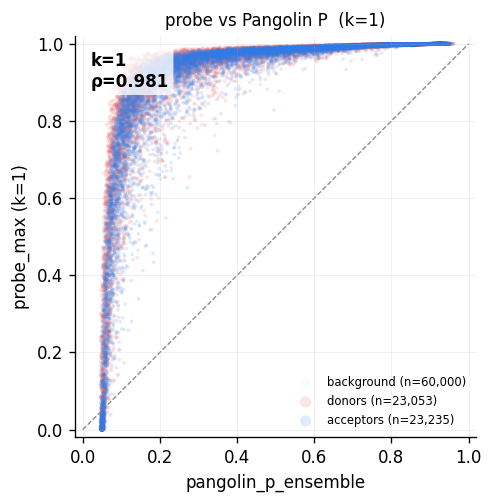

saved paper_figures/figure_scatter_pangolin_k108.svg and paper_figures/figure_scatter_pangolin_k108.png


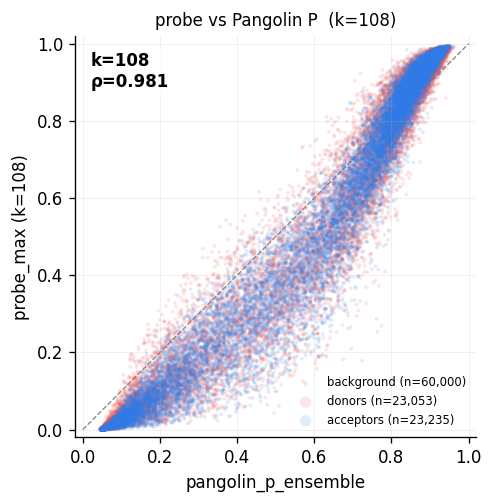

saved paper_figures/figure_scatter_pangolin_k56.svg and paper_figures/figure_scatter_pangolin_k56.png


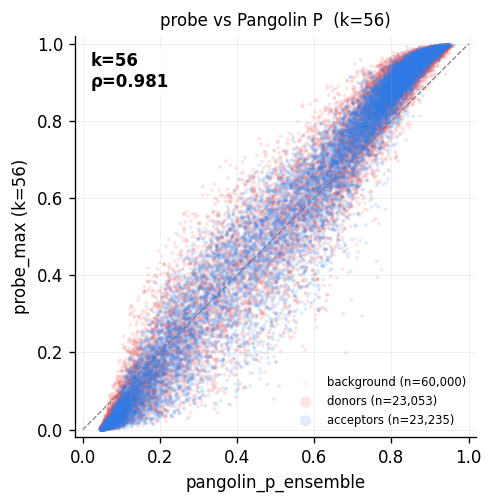

saved paper_figures/figure_scatter_pangolin_rescaled_k1.svg and paper_figures/figure_scatter_pangolin_rescaled_k1.png


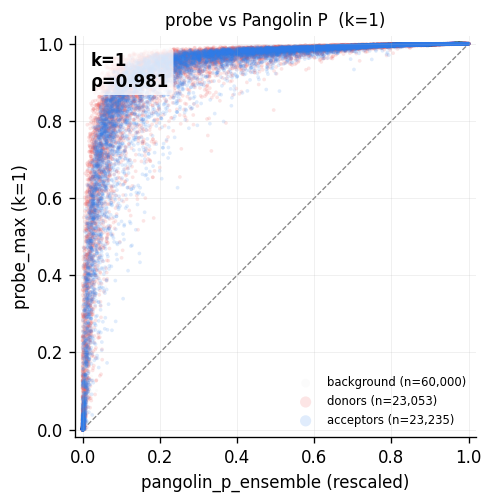

saved paper_figures/figure_scatter_pangolin_rescaled_k108.svg and paper_figures/figure_scatter_pangolin_rescaled_k108.png


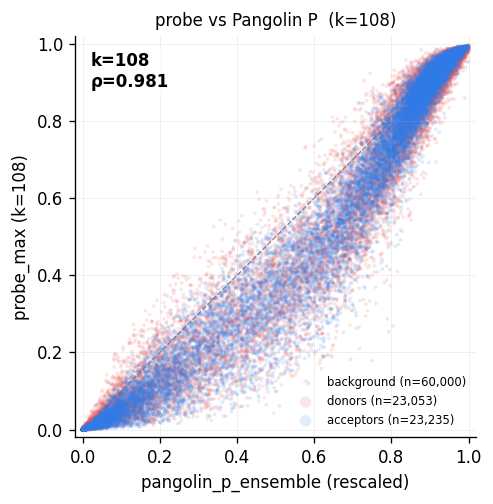

saved paper_figures/figure_scatter_pangolin_rescaled_k56.svg and paper_figures/figure_scatter_pangolin_rescaled_k56.png


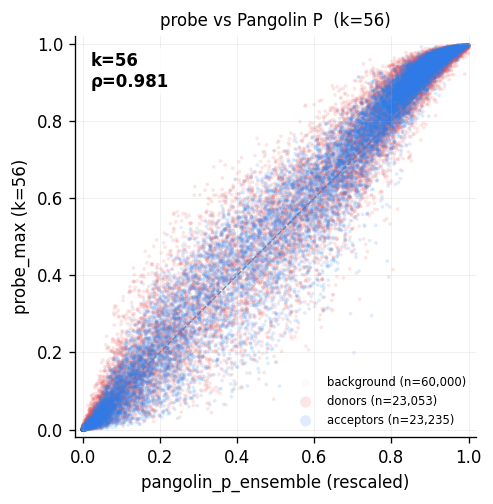

saved paper_figures/figure_scatter_spliceai_k1.svg and paper_figures/figure_scatter_spliceai_k1.png


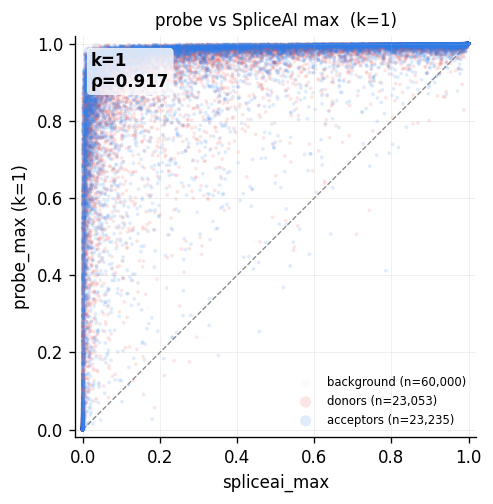

saved paper_figures/figure_scatter_spliceai_k108.svg and paper_figures/figure_scatter_spliceai_k108.png


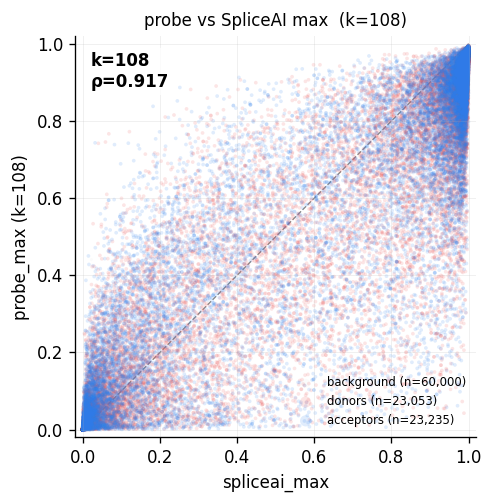

saved paper_figures/figure_scatter_spliceai_k75.svg and paper_figures/figure_scatter_spliceai_k75.png


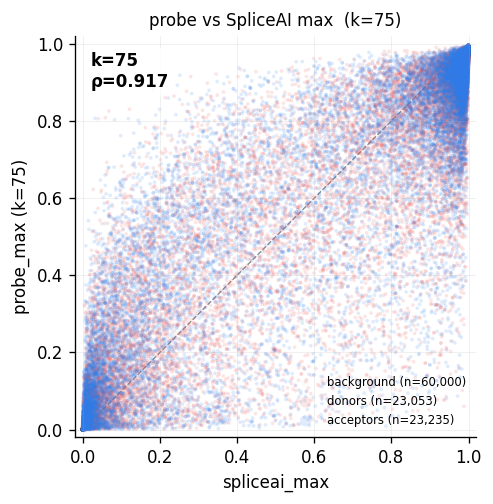

In [16]:
# Emit one standalone figure per (reference, k). Filenames let you pick favourites.
_K_DEFAULT = _resolve_default_k()
_K_PANG = float(globals().get('_kbest', {}).get('Pangolin P', 56.0))   # rescaled-Pangolin optimum
_K_SPL  = float(globals().get('_kbest', {}).get('SpliceAI max', 75.0)) # SpliceAI optimum
print(f'k values: 1, default={_K_DEFAULT:.0f}, pangolin-opt={_K_PANG:.0f}, spliceai-opt={_K_SPL:.0f}')

_combos = [
    ('pangolin',          False, 1.0),
    ('pangolin',          False, _K_DEFAULT),
    ('pangolin',          False, _K_PANG),
    ('pangolin_rescaled', True,  1.0),
    ('pangolin_rescaled', True,  _K_DEFAULT),
    ('pangolin_rescaled', True,  _K_PANG),
    ('spliceai',          False, 1.0),
    ('spliceai',          False, _K_DEFAULT),
    ('spliceai',          False, _K_SPL),
]
for _tag, _rs, _k in _combos:
    _ref = 'spliceai' if _tag == 'spliceai' else 'pangolin'
    _fig = scatter_probe_vs_ref(_k, ref=_ref, rescale_pang=_rs)
    save_figure(_fig, f'figure_scatter_{_tag}_k{int(round(_k))}')
    plt.show()

## 7. Figure: acceptor-vs-donor discrimination at true splice sites

Supports the claim that *given a position is a true splice site, the probe assigns it to the correct class (acceptor vs donor) essentially every time*.

For each held-out true splice site (label = acceptor or donor), call it "acceptor" if `probe_acc > probe_don` and "donor" otherwise. Same procedure for SpliceAI as a reference. The signed difference `acc − don` is plotted alongside as a supporting density view.

This is a 2-class problem on a curated set (~46k positions across chr1+chr9), not the full chrom-wide binary detection task in §6.

In [17]:
# Load only the columns we need at true-splice-site positions, both chroms.
# Probe outputs are corrected with the production k (~502) at load time —
# argmax(acc, don) is k-invariant so confusion-matrix accuracy is identical to
# raw, but the filter cutoff in the top-N% confidence subset uses the corrected
# scale, and the signed-difference histogram reflects corrected probabilities.

def load_true_site_scores(scores_dir=BENCH_SCORES_DIR, chroms=None,
                          correction_k=None):
    if chroms is None:
        chroms = BENCH_CHROMS
    if correction_k is None:
        correction_k = _resolve_default_correction_k()
    cols = ["label", "probe_none", "probe_acc", "probe_don",
            "spliceai_acc", "spliceai_don"]
    out = {c: [] for c in cols}
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        if not path.exists():
            print(f"  [skip] {path} missing")
            continue
        t = pq.read_table(str(path), columns=cols)
        lbl = t["label"].to_numpy().astype(np.int8)
        mask = (lbl == 1) | (lbl == 2)
        for c in cols:
            arr = t[c].to_numpy()[mask]
            if c == "label":
                out[c].append(arr.astype(np.int8))
            else:
                out[c].append(arr.astype(np.float32))
    arrs = {c: np.concatenate(v) for c, v in out.items() if v}

    if correction_k != 1.0:
        k = np.float32(correction_k)
        pn, pa_, pd_ = arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"]
        s = pn * k + pa_ + pd_
        s = np.maximum(s, np.float32(1e-12))
        arrs["probe_none"] = (pn * k) / s
        arrs["probe_acc"]  = pa_ / s
        arrs["probe_don"]  = pd_ / s
    arrs["_correction_k"] = correction_k
    return arrs


ad_arrays = load_true_site_scores()
n_acc = int((ad_arrays["label"] == 1).sum())
n_don = int((ad_arrays["label"] == 2).sum())
print(f"loaded {len(ad_arrays['label']):,} true splice sites  "
      f"(acceptors={n_acc:,}, donors={n_don:,}, "
      f"correction_k={ad_arrays['_correction_k']:.2f})")


loaded 46,288 true splice sites  (acceptors=23,235, donors=23,053, correction_k=108.14)


saved paper_figures/figure_ad_discrimination.svg and paper_figures/figure_ad_discrimination.png


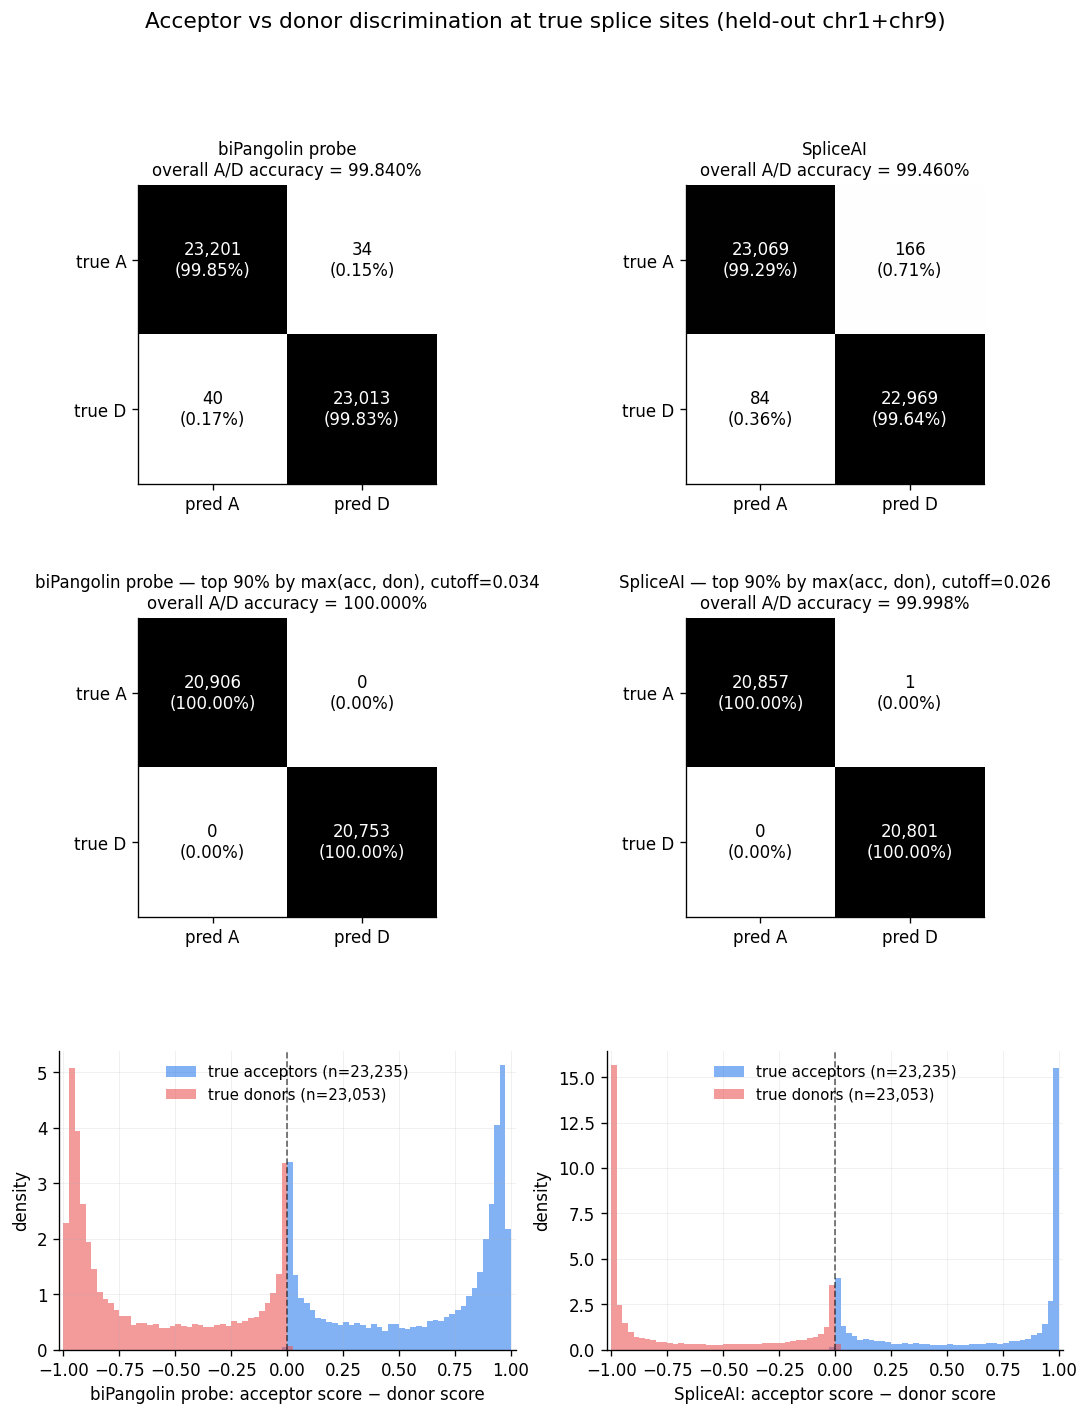

In [24]:
# Confusion matrices + signed-difference histograms for both methods.
# Three rows:
#   row 1: full confusion matrix (all true sites)
#   row 2: confusion matrix restricted to the top 90% of true sites by
#          per-method confidence (= max of acc / don score). Drops the bottom
#          decile where the method effectively says "this isn't a splice site"
#          and argmax(acc, don) is just noise.
#   row 3: signed-difference histogram (acc - don) coloured by true class.

KEEP_PCT_DEFAULT = 0.9


def _ad_predict(acc_scores, don_scores):
    return np.where(acc_scores > don_scores, 1, 2).astype(np.int8)


def _confusion_2class(true, pred):
    cm = np.zeros((2, 2), dtype=np.int64)
    for ti, tlab in enumerate((1, 2)):
        for pi, plab in enumerate((1, 2)):
            cm[ti, pi] = int(((true == tlab) & (pred == plab)).sum())
    return cm


def _draw_confusion(ax, cm, title):
    row_sums = cm.sum(axis=1).clip(1)
    cm_norm = cm / row_sums[:, None]
    overall_acc = float(np.diag(cm).sum() / max(cm.sum(), 1))
    ax.imshow(cm_norm, cmap="Greys", vmin=0, vmax=1, aspect="equal")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred A", "pred D"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["true A", "true D"])
    for i in range(2):
        for j in range(2):
            txt_color = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(j, i, f"{cm[i, j]:,}\n({cm_norm[i, j]*100:.2f}%)",
                    ha="center", va="center", color=txt_color, fontsize=10)
    ax.set_title(f"{title}\noverall A/D accuracy = {overall_acc*100:.3f}%",
                 fontsize=10)
    ax.grid(False)


def plot_ad_discrimination(arrays, keep_pct=KEEP_PCT_DEFAULT):
    label = arrays["label"]
    is_acc = label == 1
    is_don = label == 2

    methods = [
        ("biPangolin probe", arrays["probe_acc"],   arrays["probe_don"]),
        ("SpliceAI",         arrays["spliceai_acc"], arrays["spliceai_don"]),
    ]

    fig, axes = plt.subplots(3, len(methods), figsize=(5.4 * len(methods), 12.6),
                              gridspec_kw={"height_ratios": [1, 1, 1], "hspace": 0.45})

    for col, (name, acc_s, don_s) in enumerate(methods):
        pred = _ad_predict(acc_s, don_s)

        # Row 1: full confusion matrix
        cm_full = _confusion_2class(label, pred)
        _draw_confusion(axes[0, col], cm_full, name)

        # Row 2: top-keep_pct by max(acc, don)
        confidence = np.maximum(acc_s, don_s)
        cutoff = float(np.quantile(confidence, 1.0 - keep_pct))
        keep = confidence >= cutoff
        cm_kept = _confusion_2class(label[keep], pred[keep])
        kept_title = (f"{name} — top {int(round(keep_pct*100))}%"
                      f" by max(acc, don), cutoff={cutoff:.3f}")
        _draw_confusion(axes[1, col], cm_kept, kept_title)

        # Row 3: signed-difference histogram
        ax = axes[2, col]
        diff = (acc_s - don_s)
        bins = np.linspace(-1, 1, 81)
        ax.hist(diff[is_acc], bins=bins, color=ACC_COLOR, alpha=0.6,
                label=f"true acceptors (n={int(is_acc.sum()):,})", density=True)
        ax.hist(diff[is_don], bins=bins, color=DON_COLOR, alpha=0.6,
                label=f"true donors (n={int(is_don.sum()):,})", density=True)
        ax.axvline(0, color="black", lw=1, ls="--", alpha=0.6)
        ax.set_xlabel(f"{name}: acceptor score − donor score")
        ax.set_ylabel("density")
        ax.set_xlim(-1.02, 1.02)
        ax.legend(frameon=False, fontsize=9, loc="upper center")

    fig.suptitle("Acceptor vs donor discrimination at true splice sites "
                 "(held-out chr1+chr9)", y=0.995, fontsize=13)
    return fig


fig = plot_ad_discrimination(ad_arrays)
save_figure(fig, "figure_ad_discrimination")
plt.show()


## 8. Correlation analysis across models

Spearman ρ between per-position score columns, computed by streaming `bench_scores/*.parquet` in 1M-row batches via `benchmark/bench_correlations.py`. Spearman (rank-based) is far less sensitive than Pearson to the probe's softmax saturation and to the choice of Bayesian correction k.

The figures below restrict to true splice-site positions (acceptor and donor subsets shown separately):

- **biPangolin vs Pangolin matrix** — deliberately rectangular: biPangolin probe outputs as rows (ensemble `probe_max`, per-tissue P-side `probe_max_{tissue}`, and per-tissue PSI-side `probe_max_psi_{tissue}` when present), Pangolin scores as columns (P and PSI per tissue, plus ensembles). The PSI-side probe rows against the Pangolin PSI columns are the apples-to-apples comparison.
- **Scatter plots** — the raw per-position relationships behind selected ρ values.
- **Tissue-specificity bars** — whether each tissue probe agrees most with its matched-tissue Pangolin output.

If `bench_metrics/correlations.npz` doesn't exist or is stale:

```bash
python benchmark/bench_correlations.py --scores bench_scores/ --out bench_metrics/correlations.npz
```


In [19]:
# Load correlation matrices produced by benchmark/bench_correlations.py.
# Values are Spearman ρ.

CORR_NPZ = Path("bench_metrics/correlations.npz")
if not CORR_NPZ.exists():
    raise FileNotFoundError(
        f"{CORR_NPZ} not found. Run:\n"
        "  python benchmark/bench_correlations.py --scores bench_scores/ --out bench_metrics/correlations.npz"
    )

corr_data = np.load(CORR_NPZ)
corr_columns = list(corr_data["columns"])
corr_counts = {s: int(corr_data[f"n_{s}"][0]) for s in ("all", "acceptors", "donors", "nonsites")}
print(f"loaded {CORR_NPZ}")
print(f"  columns ({len(corr_columns)}): {corr_columns}")
print(f"  subset counts: {corr_counts}")

def _corr_submatrix(subset, column_names):
    full = corr_data[f"corr_{subset}"]
    idx = [corr_columns.index(c) for c in column_names]
    return full[np.ix_(idx, idx)]

def _plot_corr_heatmap(ax, M, labels, title=None, vmin=-1, vmax=1, cmap="RdBu_r",
                       annotate=True, annot_fontsize=8):
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap, aspect="equal")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.grid(False)
    if annotate:
        # Text-colour threshold = midpoint of the actual colour-mapped range.
        lo = im.norm.vmin if im.norm.vmin is not None else float(np.nanmin(M))
        hi = im.norm.vmax if im.norm.vmax is not None else float(np.nanmax(M))
        thr = lo + 0.55 * (hi - lo)
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M[i, j]
                if np.isfinite(v):
                    color = "white" if v > thr else "black"
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color=color, fontsize=annot_fontsize)
    if title:
        ax.set_title(title, fontsize=10)
    return im


loaded bench_metrics/correlations.npz
  columns (50): [np.str_('probe_none'), np.str_('probe_acc'), np.str_('probe_don'), np.str_('pangolin_p_heart'), np.str_('pangolin_p_liver'), np.str_('pangolin_p_brain'), np.str_('pangolin_p_testis'), np.str_('pangolin_psi_heart'), np.str_('pangolin_psi_liver'), np.str_('pangolin_psi_brain'), np.str_('pangolin_psi_testis'), np.str_('spliceai_acc'), np.str_('spliceai_don'), np.str_('probe_none_heart'), np.str_('probe_acc_heart'), np.str_('probe_don_heart'), np.str_('probe_none_liver'), np.str_('probe_acc_liver'), np.str_('probe_don_liver'), np.str_('probe_none_brain'), np.str_('probe_acc_brain'), np.str_('probe_don_brain'), np.str_('probe_none_testis'), np.str_('probe_acc_testis'), np.str_('probe_don_testis'), np.str_('probe_none_psi_heart'), np.str_('probe_acc_psi_heart'), np.str_('probe_don_psi_heart'), np.str_('probe_none_psi_liver'), np.str_('probe_acc_psi_liver'), np.str_('probe_don_psi_liver'), np.str_('probe_none_psi_brain'), np.str_('probe_a

saved paper_figures/figure_correlation_bipangolin_vs_pangolin.svg and paper_figures/figure_correlation_bipangolin_vs_pangolin.png


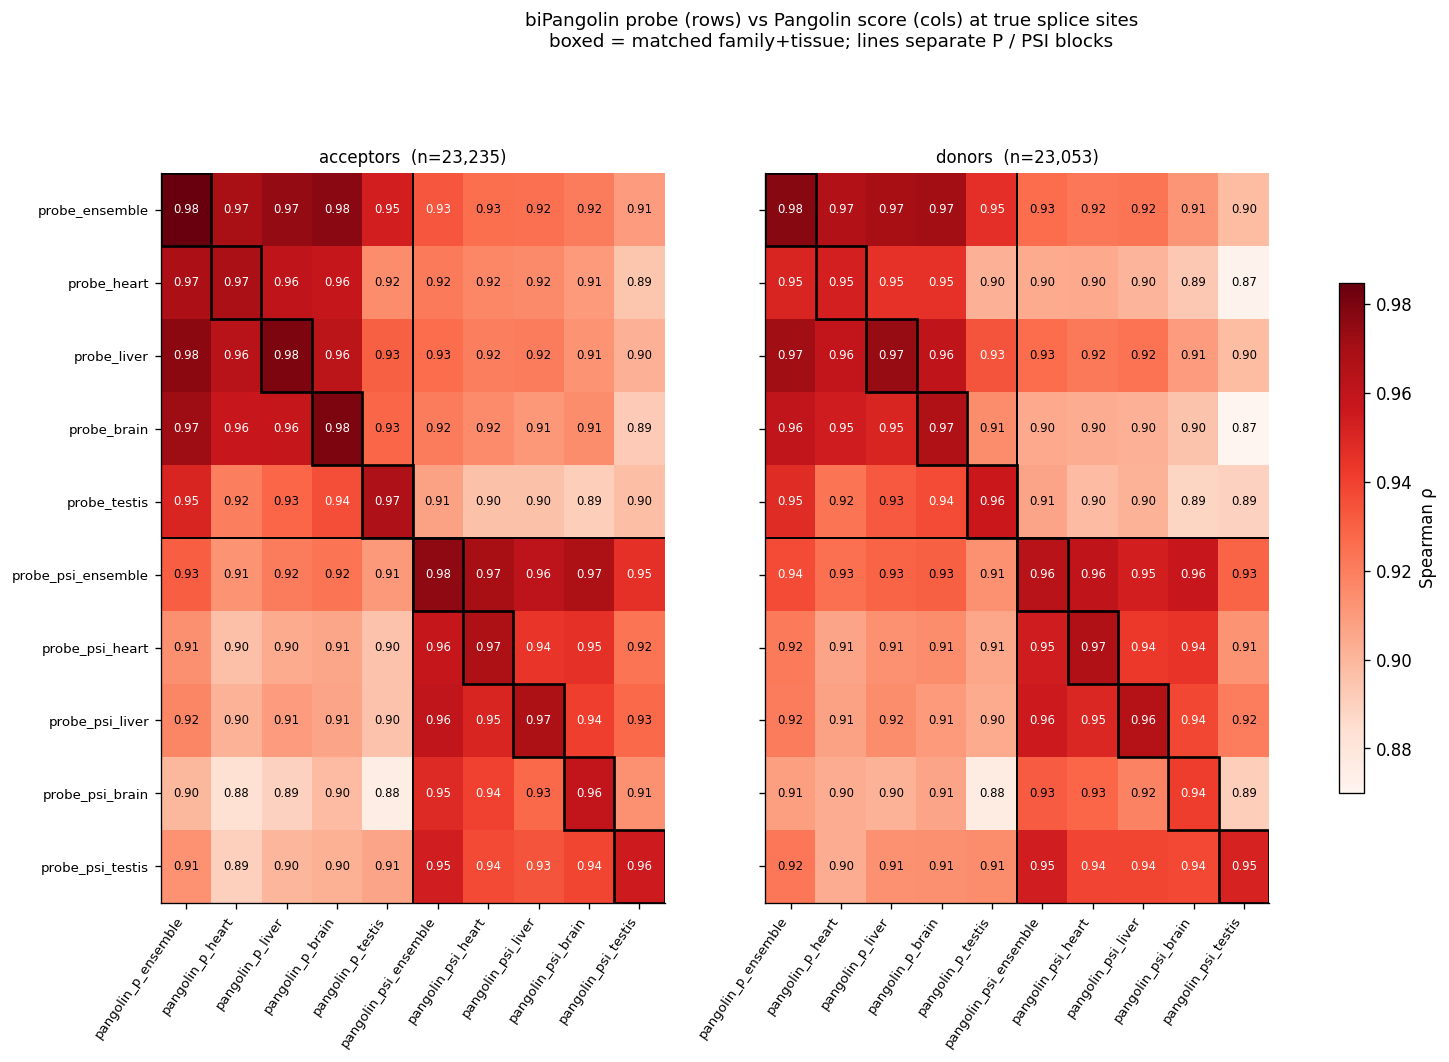

In [20]:
# Correlation matrix: biPangolin probes (rows) vs Pangolin scores (columns).
# Deliberately rectangular / non-symmetric. Spearman ρ from correlations.npz, at
# true acceptor and donor sites separately.
#
# Ordering: ensemble first within each family, then per tissue.
#   Rows : P-side probe (ensemble + per tissue), then PSI-side probe (ensemble + per tissue).
#   Cols : Pangolin P (ensemble + per tissue), then Pangolin PSI (ensemble + per tissue).
# The PSI-side probe rows against the Pangolin PSI columns are the apples-to-apples
# comparison (probe trained on the same trunk fine-tune as the score it predicts).
# Black-outlined cells = matched family + tissue. Dashed lines separate P / PSI blocks.

from matplotlib.patches import Rectangle

def _row_spec():
    # (column_name, display_label, family, tissue)
    spec = [("probe_max", "probe_ensemble", "P", "ensemble")]
    for t in ("heart", "liver", "brain", "testis"):
        spec.append((f"probe_max_{t}", f"probe_{t}", "P", t))
    spec.append(("probe_max_psi_ensemble", "probe_psi_ensemble", "PSI", "ensemble"))
    for t in ("heart", "liver", "brain", "testis"):
        spec.append((f"probe_max_psi_{t}", f"probe_psi_{t}", "PSI", t))
    return [s for s in spec if s[0] in corr_columns]

def _col_spec():
    spec = [("pangolin_p_ensemble", "pangolin_p_ensemble", "P", "ensemble")]
    for t in ("heart", "liver", "brain", "testis"):
        spec.append((f"pangolin_p_{t}", f"pangolin_p_{t}", "P", t))
    spec.append(("pangolin_psi_ensemble", "pangolin_psi_ensemble", "PSI", "ensemble"))
    for t in ("heart", "liver", "brain", "testis"):
        spec.append((f"pangolin_psi_{t}", f"pangolin_psi_{t}", "PSI", t))
    return [s for s in spec if s[0] in corr_columns]

def _corr_rect(subset, row_cols, col_cols):
    full = corr_data[f"corr_{subset}"]
    ri = [corr_columns.index(c) for c in row_cols]
    ci = [corr_columns.index(c) for c in col_cols]
    return full[np.ix_(ri, ci)]

def _block_boundary(spec):
    """Index of the first row/col whose family differs from the previous one."""
    for i in range(1, len(spec)):
        if spec[i][2] != spec[i - 1][2]:
            return i
    return None

def plot_bipangolin_vs_pangolin_corr(subsets=("acceptors", "donors")):
    rows = _row_spec()
    cols = _col_spec()
    if not rows or not cols:
        print("  [skip] required columns missing from correlations.npz")
        return None

    row_cols = [r[0] for r in rows]; row_lbls = [r[1] for r in rows]
    col_cols = [c[0] for c in cols]; col_lbls = [c[1] for c in cols]
    row_bnd = _block_boundary(rows)
    col_bnd = _block_boundary(cols)

    mats = {s: _corr_rect(s, row_cols, col_cols) for s in subsets}
    vmin = min(float(np.nanmin(M)) for M in mats.values())
    vmax = max(float(np.nanmax(M)) for M in mats.values())
    thr = vmin + 0.55 * (vmax - vmin)

    n = len(subsets)
    fig, axes = plt.subplots(1, n, figsize=(0.62 * len(cols) * n + 2.5, 0.55 * len(rows) + 2.4),
                             squeeze=False)
    axes = axes[0]
    for pi, (ax, subset) in enumerate(zip(axes, subsets)):
        M = mats[subset]
        im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap="Reds", aspect="auto")
        ax.set_xticks(np.arange(len(cols)))
        ax.set_xticklabels(col_lbls, rotation=55, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(rows)))
        if pi == 0:
            ax.set_yticklabels(row_lbls, fontsize=8)
        else:
            ax.set_yticklabels([])          # avoid overlap on right panel
        ax.grid(False)

        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                v = M[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                            color="white" if v > thr else "black", fontsize=7)

        # Block separators (P vs PSI)
        if row_bnd is not None:
            ax.axhline(row_bnd - 0.5, color="black", lw=1.2)
        if col_bnd is not None:
            ax.axvline(col_bnd - 0.5, color="black", lw=1.2)

        # Matched family + tissue boxes
        for i, r in enumerate(rows):
            for j, c in enumerate(cols):
                if r[2] == c[2] and r[3] == c[3]:
                    ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                           edgecolor="black", lw=1.6))
        ax.set_title(f"{subset}  (n={corr_counts[subset]:,})", fontsize=10)

    fig.colorbar(im, ax=axes, shrink=0.7, label="Spearman ρ")
    fig.suptitle("biPangolin probe (rows) vs Pangolin score (cols) at true splice sites\n"
                 "boxed = matched family+tissue; lines separate P / PSI blocks",
                 y=1.05, fontsize=11)
    return fig

fig = plot_bipangolin_vs_pangolin_corr()
if fig is not None:
    save_figure(fig, "figure_correlation_bipangolin_vs_pangolin")
    plt.show()


  loaded 46,288 true splice sites  (per-tissue P-side probes: True, PSI-side probes: True, correction_k=108.14)
saved paper_figures/figure_correlation_scatters.svg and paper_figures/figure_correlation_scatters.png


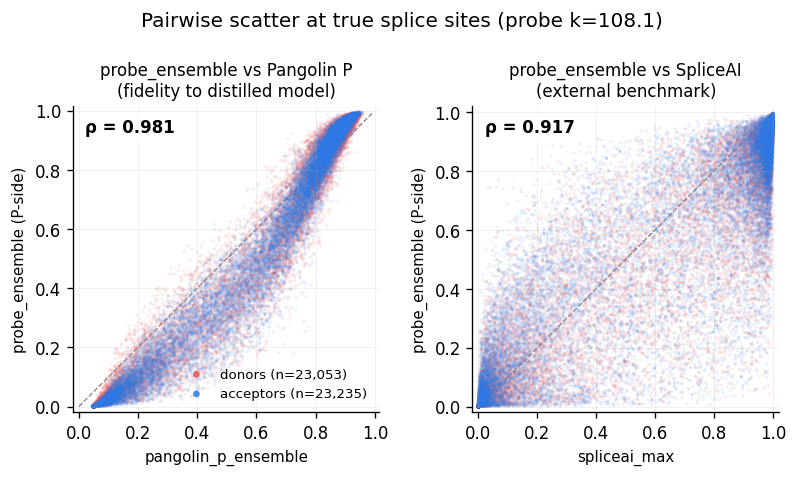

In [21]:
# Scatter visualisations behind the Spearman ρ values. The matrices above carry
# every pairwise correlation number; scatters are reserved for the two
# relationships where the *shape* of the cloud matters, coloured by true class
# (acceptor / donor), restricted to true splice sites:
#   1. probe_ensemble vs Pangolin P — fidelity to the model the probe distils
#   2. probe_ensemble vs SpliceAI   — independent external gold standard
# Probe outputs have the default Bayesian k correction applied (from optimal_correction.json).


def _load_default_k():
    """Resolve the production k value from optimal_correction.json."""
    candidates = [
        Path("src/bipangolin/data/probes/optimal_correction.json"),
        Path("bipangolin_probes/optimal_correction.json"),
    ]
    for p in candidates:
        if p.exists():
            with open(p) as f:
                return float(json.load(f)["empirical_sweep"]["best_k"])
    return 502.0  # safe fallback


def _correct_triple(p_none, p_acc, p_don, k):
    """Apply Bayesian none-class correction; returns (none, acc, don) at given k."""
    if k == 1.0:
        return p_none, p_acc, p_don
    k = np.float32(k)
    s = p_none * k + p_acc + p_don
    s = np.maximum(s, np.float32(1e-12))
    return (p_none * k) / s, p_acc / s, p_don / s


def _load_scatter_arrays(scores_dir=BENCH_SCORES_DIR, chroms=None):
    if chroms is None:
        chroms = BENCH_CHROMS
    pq_schema = pq.read_schema(str(scores_dir / f"{chroms[0]}.parquet")).names
    needed_native = [
        "label",
        "probe_none", "probe_acc", "probe_don",
        "spliceai_acc", "spliceai_don",
        "pangolin_p_heart", "pangolin_p_liver", "pangolin_p_brain", "pangolin_p_testis",
        "pangolin_psi_heart", "pangolin_psi_liver", "pangolin_psi_brain", "pangolin_psi_testis",
    ]
    tissues = ("heart", "liver", "brain", "testis")
    has_pt = all(f"probe_{ch}_{t}" in pq_schema
                 for ch in ("none", "acc", "don") for t in tissues)
    has_pt_psi = all(f"probe_{ch}_psi_{t}" in pq_schema
                     for ch in ("none", "acc", "don") for t in tissues)
    if has_pt:
        for t in tissues:
            needed_native += [f"probe_none_{t}", f"probe_acc_{t}", f"probe_don_{t}"]
    if has_pt_psi:
        for t in tissues:
            needed_native += [f"probe_none_psi_{t}", f"probe_acc_psi_{t}", f"probe_don_psi_{t}"]
    out = {c: [] for c in needed_native}
    for chrom in chroms:
        path = scores_dir / f"{chrom}.parquet"
        if not path.exists():
            print(f"  [skip] {path} missing")
            continue
        t = pq.read_table(str(path), columns=needed_native)
        lbl = t["label"].to_numpy().astype(np.int8)
        mask = (lbl == 1) | (lbl == 2)
        for c in needed_native:
            arr = t[c].to_numpy()[mask]
            out[c].append(arr.astype(np.int8 if c == "label" else np.float32))
    arrs = {c: np.concatenate(v) for c, v in out.items() if v}

    # Apply default-k correction to all probe triples (ensemble + per-tissue
    # P-side + per-tissue PSI-side).
    k = _load_default_k()
    arrs["_correction_k"] = k
    cn, ca, cd = _correct_triple(arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"], k)
    arrs["probe_none"], arrs["probe_acc"], arrs["probe_don"] = cn, ca, cd
    if has_pt:
        for t in tissues:
            cn, ca, cd = _correct_triple(
                arrs[f"probe_none_{t}"], arrs[f"probe_acc_{t}"], arrs[f"probe_don_{t}"], k)
            arrs[f"probe_none_{t}"] = cn
            arrs[f"probe_acc_{t}"] = ca
            arrs[f"probe_don_{t}"] = cd
    if has_pt_psi:
        for t in tissues:
            cn, ca, cd = _correct_triple(
                arrs[f"probe_none_psi_{t}"], arrs[f"probe_acc_psi_{t}"], arrs[f"probe_don_psi_{t}"], k)
            arrs[f"probe_none_psi_{t}"] = cn
            arrs[f"probe_acc_psi_{t}"] = ca
            arrs[f"probe_don_psi_{t}"] = cd

    # Derived columns (from corrected values)
    p_cols = [arrs[f"pangolin_p_{t}"] for t in tissues]
    psi_cols = [arrs[f"pangolin_psi_{t}"] for t in tissues]
    arrs["pangolin_p_ensemble"]   = np.mean(np.stack(p_cols, axis=0), axis=0)
    arrs["pangolin_psi_ensemble"] = np.mean(np.stack(psi_cols, axis=0), axis=0)
    arrs["probe_max"]    = np.maximum(arrs["probe_acc"], arrs["probe_don"])
    arrs["spliceai_max"] = np.maximum(arrs["spliceai_acc"], arrs["spliceai_don"])
    if has_pt:
        for t in tissues:
            arrs[f"probe_max_{t}"] = np.maximum(arrs[f"probe_acc_{t}"], arrs[f"probe_don_{t}"])
    if has_pt_psi:
        for t in tissues:
            arrs[f"probe_max_psi_{t}"] = np.maximum(arrs[f"probe_acc_psi_{t}"], arrs[f"probe_don_psi_{t}"])
        # PSI-side probe ensemble: tissue-mean of acc / don, then max (mirrors
        # pangolin_psi_ensemble and bench_correlations' probe_max_psi_ensemble).
        acc_psi = np.mean(np.stack([arrs[f"probe_acc_psi_{t}"] for t in tissues], axis=0), axis=0)
        don_psi = np.mean(np.stack([arrs[f"probe_don_psi_{t}"] for t in tissues], axis=0), axis=0)
        arrs["probe_max_psi_ensemble"] = np.maximum(acc_psi, don_psi)
    return arrs, has_pt, has_pt_psi


def _spearman_rho(x, y):
    """Quick exact Spearman ρ on small arrays (only ~46k points here)."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    xr = np.argsort(np.argsort(x[mask], kind="quicksort"))
    yr = np.argsort(np.argsort(y[mask], kind="quicksort"))
    xr = xr.astype(np.float64); yr = yr.astype(np.float64)
    xr -= xr.mean(); yr -= yr.mean()
    denom = np.sqrt((xr * xr).sum() * (yr * yr).sum())
    return float((xr * yr).sum() / denom) if denom > 0 else np.nan


# Pretty axis labels for the ensemble columns.
_SCATTER_LABEL = {
    "probe_max": "probe_ensemble (P-side)",
    "probe_max_psi_ensemble": "probe_ensemble (PSI-side)",
    "pangolin_p_ensemble": "pangolin_p_ensemble",
    "pangolin_psi_ensemble": "pangolin_psi_ensemble",
    "spliceai_max": "spliceai_max",
}


def plot_correlation_scatters(arrs, has_pt, has_pt_psi):
    label = arrs["label"]
    is_acc = label == 1
    is_don = label == 2

    # Two scatters only: the matrices carry every pairwise ρ, so scatters are
    # reserved for the comparisons where cloud shape (saturation, bias, tails)
    # adds something a single number can't. Both use the P-side probe ensemble.
    pairs = [
        ("pangolin_p_ensemble", "probe_max",
         "probe_ensemble vs Pangolin P\n(fidelity to distilled model)"),
        ("spliceai_max", "probe_max",
         "probe_ensemble vs SpliceAI\n(external benchmark)"),
    ]

    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(3.4 * n, 3.6))
    if n == 1:
        axes = [axes]
    for ax, (xkey, ykey, title) in zip(axes, pairs):
        x = arrs[xkey]; y = arrs[ykey]
        ax.scatter(x[is_don], y[is_don], s=4, alpha=0.10, c=DON_COLOR,
                   edgecolors="none", rasterized=True, label=f"donors (n={int(is_don.sum()):,})")
        ax.scatter(x[is_acc], y[is_acc], s=4, alpha=0.10, c=ACC_COLOR,
                   edgecolors="none", rasterized=True, label=f"acceptors (n={int(is_acc.sum()):,})")
        lo = float(min(np.nanmin(x), np.nanmin(y)))
        hi = float(max(np.nanmax(x), np.nanmax(y)))
        ax.plot([lo, hi], [lo, hi], color="#888888", lw=0.8, ls="--", zorder=0)
        rho = _spearman_rho(x, y)
        ax.text(0.04, 0.96, f"ρ = {rho:.3f}",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8))
        ax.set_xlabel(_SCATTER_LABEL.get(xkey, xkey), fontsize=9)
        ax.set_ylabel(_SCATTER_LABEL.get(ykey, ykey), fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(lo - 0.02, hi + 0.02)
        ax.set_ylim(lo - 0.02, hi + 0.02)
        ax.set_aspect("equal")
        if ax is axes[0]:
            leg = ax.legend(frameon=False, fontsize=8, loc="lower right",
                            markerscale=2)
            for lh in leg.legend_handles:
                lh.set_alpha(0.9)
    fig.suptitle(f"Pairwise scatter at true splice sites (probe k={arrs['_correction_k']:.1f})",
                 y=1.04, fontsize=12)
    fig.tight_layout()
    return fig


scatter_arrays, _has_pt, _has_pt_psi = _load_scatter_arrays()
print(f"  loaded {len(scatter_arrays['label']):,} true splice sites  "
      f"(per-tissue P-side probes: {_has_pt}, PSI-side probes: {_has_pt_psi}, "
      f"correction_k={scatter_arrays['_correction_k']:.2f})")
fig = plot_correlation_scatters(scatter_arrays, _has_pt, _has_pt_psi)
save_figure(fig, "figure_correlation_scatters")
plt.show()


saved paper_figures/figure_tissue_probe_pangolin_corr.svg and paper_figures/figure_tissue_probe_pangolin_corr.png


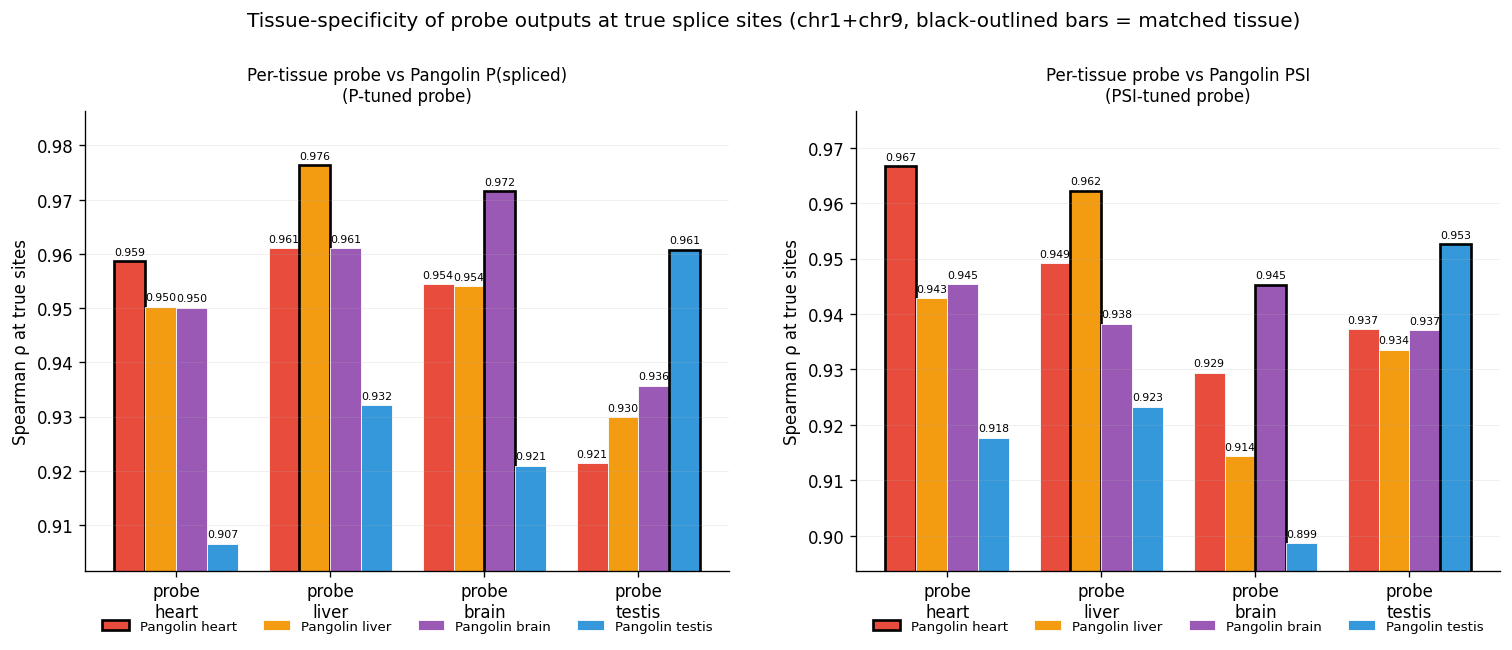

In [22]:
# Tissue-specificity check: does each tissue probe correlate more strongly with
# its matched-tissue Pangolin output than with mismatched tissues?
#
# Important: the LEFT panel uses the P-tuned probe (`probe_max_{tissue}`) and
# compares it against Pangolin P(spliced). The RIGHT panel uses the PSI-tuned
# probe (`probe_max_psi_{tissue}`) against Pangolin PSI. Each side uses the
# probe trained on activations from the corresponding Pangolin model
# fine-tune, so the comparison is apples-to-apples.
#
# If the parquet doesn't have PSI-side probes (older bench_score run), the
# right panel falls back to the P-tuned probe with a warning in the title.

def plot_tissue_probe_pangolin_corr(arrs, has_pt, has_pt_psi):
    if not has_pt:
        print("  [skip] per-tissue probe columns not in parquet — "
              "rerun bench_score.py with --per-tissue-probes")
        return None

    label = arrs["label"]
    site_mask = label != 0
    tissues = ("heart", "liver", "brain", "testis")

    rho_p   = np.full((4, 4), np.nan)
    rho_psi = np.full((4, 4), np.nan)
    # LEFT panel: P-tuned probe vs Pangolin P
    for i, pt in enumerate(tissues):
        probe = arrs[f"probe_max_{pt}"][site_mask]
        for j, pgt in enumerate(tissues):
            rho_p[i, j] = _spearman_rho(probe, arrs[f"pangolin_p_{pgt}"][site_mask])
    # RIGHT panel: PSI-tuned probe vs Pangolin PSI (or fallback)
    psi_probe_key = (lambda t: f"probe_max_psi_{t}") if has_pt_psi else (lambda t: f"probe_max_{t}")
    for i, pt in enumerate(tissues):
        probe = arrs[psi_probe_key(pt)][site_mask]
        for j, pgt in enumerate(tissues):
            rho_psi[i, j] = _spearman_rho(probe, arrs[f"pangolin_psi_{pgt}"][site_mask])

    tissue_colors = {"heart": "#e74c3c", "liver": "#f39c12",
                     "brain": "#9b59b6", "testis": "#3498db"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), sharey=False)
    x = np.arange(4)
    width = 0.20

    panel_specs = [
        (axes[0], rho_p,   "Per-tissue probe vs Pangolin P(spliced)",
         "P-tuned probe"),
        (axes[1], rho_psi, "Per-tissue probe vs Pangolin PSI",
         "PSI-tuned probe" if has_pt_psi else "P-tuned probe [PSI-side probes MISSING — re-run bench_score]"),
    ]
    for ax, M, title, subtitle in panel_specs:
        for j, pgt in enumerate(tissues):
            offset = (j - 1.5) * width
            colour = tissue_colors[pgt]
            for i, pt in enumerate(tissues):
                v = M[i, j]
                edge_w = 1.6 if i == j else 0.5
                edge_c = "black" if i == j else "white"
                ax.bar(x[i] + offset, v, width=width,
                       color=colour, edgecolor=edge_c, linewidth=edge_w,
                       label=f"Pangolin {pgt}" if i == 0 else None)
            for i, v in enumerate(M[:, j]):
                ax.text(x[i] + offset, v + 0.0008, f"{v:.3f}",
                        ha="center", va="bottom", fontsize=6.5)
        ax.set_xticks(x)
        ax.set_xticklabels([f"probe\n{t}" for t in tissues])
        ax.set_title(f"{title}\n({subtitle})", fontsize=10)
        ax.set_ylabel("Spearman ρ at true sites")
        lo = float(np.nanmin(M)); hi = float(np.nanmax(M))
        pad = max(0.005, 0.05 * (hi - lo))
        ax.set_ylim(lo - pad, hi + 2 * pad)
        ax.legend(frameon=False, fontsize=8, ncols=4, loc="upper center",
                  bbox_to_anchor=(0.5, -0.08))
        ax.grid(axis="x", visible=False)

    fig.suptitle("Tissue-specificity of probe outputs at true splice sites "
                 "(chr1+chr9, black-outlined bars = matched tissue)",
                 y=1.00, fontsize=12)
    fig.tight_layout()
    return fig


fig = plot_tissue_probe_pangolin_corr(scatter_arrays, _has_pt, _has_pt_psi)
if fig is not None:
    save_figure(fig, "figure_tissue_probe_pangolin_corr")
    plt.show()
